# Section 2: NK-cell contact and kill distributions

This notebook analyses the three experimental conditions:

- no treatment
- Rtx
- bispecific

Each row is interpreted as one NK cell. Non-empty contact-history entries are counted as contacts, and entries equal to 1 are counted as kills.

The empirical distributions are summarised first, then the Section 1 Bayesian count-model pipeline can be run on both contact counts and kill counts.

In [12]:
from __future__ import annotations

import os
import sys
from pathlib import Path
from itertools import combinations
from typing import Any

os.environ.setdefault("PYTENSOR_FLAGS", "optimizer_excluding=fusion")
os.environ.setdefault("HDF5_USE_FILE_LOCKING", "FALSE")

import arviz as az
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

import matplotlib.pyplot as plt
from matplotlib.ticker import NullLocator
import scienceplots
plt.style.use('science')

def find_project_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "section_1" / "src" / "inference.py").exists() and (candidate / "data").exists():
            return candidate
    raise RuntimeError("Could not find project root containing section_1/src/inference.py and data/.")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_ROOT = PROJECT_ROOT / "data"
RESULT_ROOT = PROJECT_ROOT / "section_2" / "results" / "analysis_1"
FIGURE_ROOT = PROJECT_ROOT / "section_2" / "figures" / "analysis_1"
RESULT_ROOT.mkdir(parents=True, exist_ok=True)
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("RESULT_ROOT:", RESULT_ROOT)
print("FIGURE_ROOT:", FIGURE_ROOT)

PROJECT_ROOT: /Users/marsian/PhD_LifeSciRes/Orca
DATA_ROOT: /Users/marsian/PhD_LifeSciRes/Orca/data
RESULT_ROOT: /Users/marsian/PhD_LifeSciRes/Orca/section_2/results/analysis_1
FIGURE_ROOT: /Users/marsian/PhD_LifeSciRes/Orca/section_2/figures/analysis_1


## load the data

For each NK cell, keep only two counts:

- `contact_count`: number of non-empty contact-history entries.
- `kill_count`: number of entries equal to 1.


In [13]:
CONDITIONS = {
    "no_treatment": {
        "label": "No treatment",
        "path": DATA_ROOT / "NT-No Treatment.csv",
    },
    "rtx": {
        "label": "Rituximab",
        "path": DATA_ROOT / "RTX-Rituximab.csv",
    },
    "bispecific": {
        "label": "Bispecific Ab",
        "path": DATA_ROOT / "Bispecific-Bispecific.csv",
    },
}

def load_history_table(path: Path, condition: str, label: str) -> pd.DataFrame:
    raw = pd.read_csv(path)

    history = raw.drop(columns="Cell").apply(pd.to_numeric, errors="coerce")
    history = history.loc[:, history.notna().any()]

    return pd.DataFrame(
        {
            "Cell": raw["Cell"],
            "condition": condition,
            "condition_label": label,
            "contact_count": history.notna().sum(axis=1).astype(int),
            "kill_count": history.fillna(0).sum(axis=1).astype(int),
        }
    )


cells = pd.concat(
    [
        load_history_table(meta["path"], condition, meta["label"])
        for condition, meta in CONDITIONS.items()
    ],
    ignore_index=True,
)

cells

,Cell,condition,condition_label,contact_count,kill_count
0,0,no_treatment,No treatment,4,0
1,1,no_treatment,No treatment,3,0
2,2,no_treatment,No treatment,1,1
3,3,no_treatment,No treatment,2,0
4,4,no_treatment,No treatment,2,1
...,...,...,...,...,...
1637,504,bispecific,Bispecific Ab,2,1
1638,505,bispecific,Bispecific Ab,2,1
1639,506,bispecific,Bispecific Ab,0,0
1640,507,bispecific,Bispecific Ab,3,1


In [14]:
counts_by_condition = {
    label: {
        "contact_counts": group["contact_count"].to_numpy(dtype=int),
        "kill_counts": group["kill_count"].to_numpy(dtype=int),
    }
    for label, group in cells.groupby("condition_label", sort=False)
}

# counts_by_condition

## Empirical contact and kill distributions

In [15]:
nt_contacts = counts_by_condition["No treatment"]["contact_counts"]
nt_kills = counts_by_condition["No treatment"]["kill_counts"]

rtx_contacts = counts_by_condition["Rituximab"]["contact_counts"]
rtx_kills = counts_by_condition["Rituximab"]["kill_counts"]

bispecific_contacts = counts_by_condition["Bispecific Ab"]["contact_counts"]
bispecific_kills = counts_by_condition["Bispecific Ab"]["kill_counts"]


contact_datasets = [
    nt_contacts,
    rtx_contacts,
    bispecific_contacts,
]

kill_datasets = [
    nt_kills,
    rtx_kills,
    bispecific_kills,
]

labels = [
    "No treatment",
    "Rituximab",
    "Bispecific Ab",
]


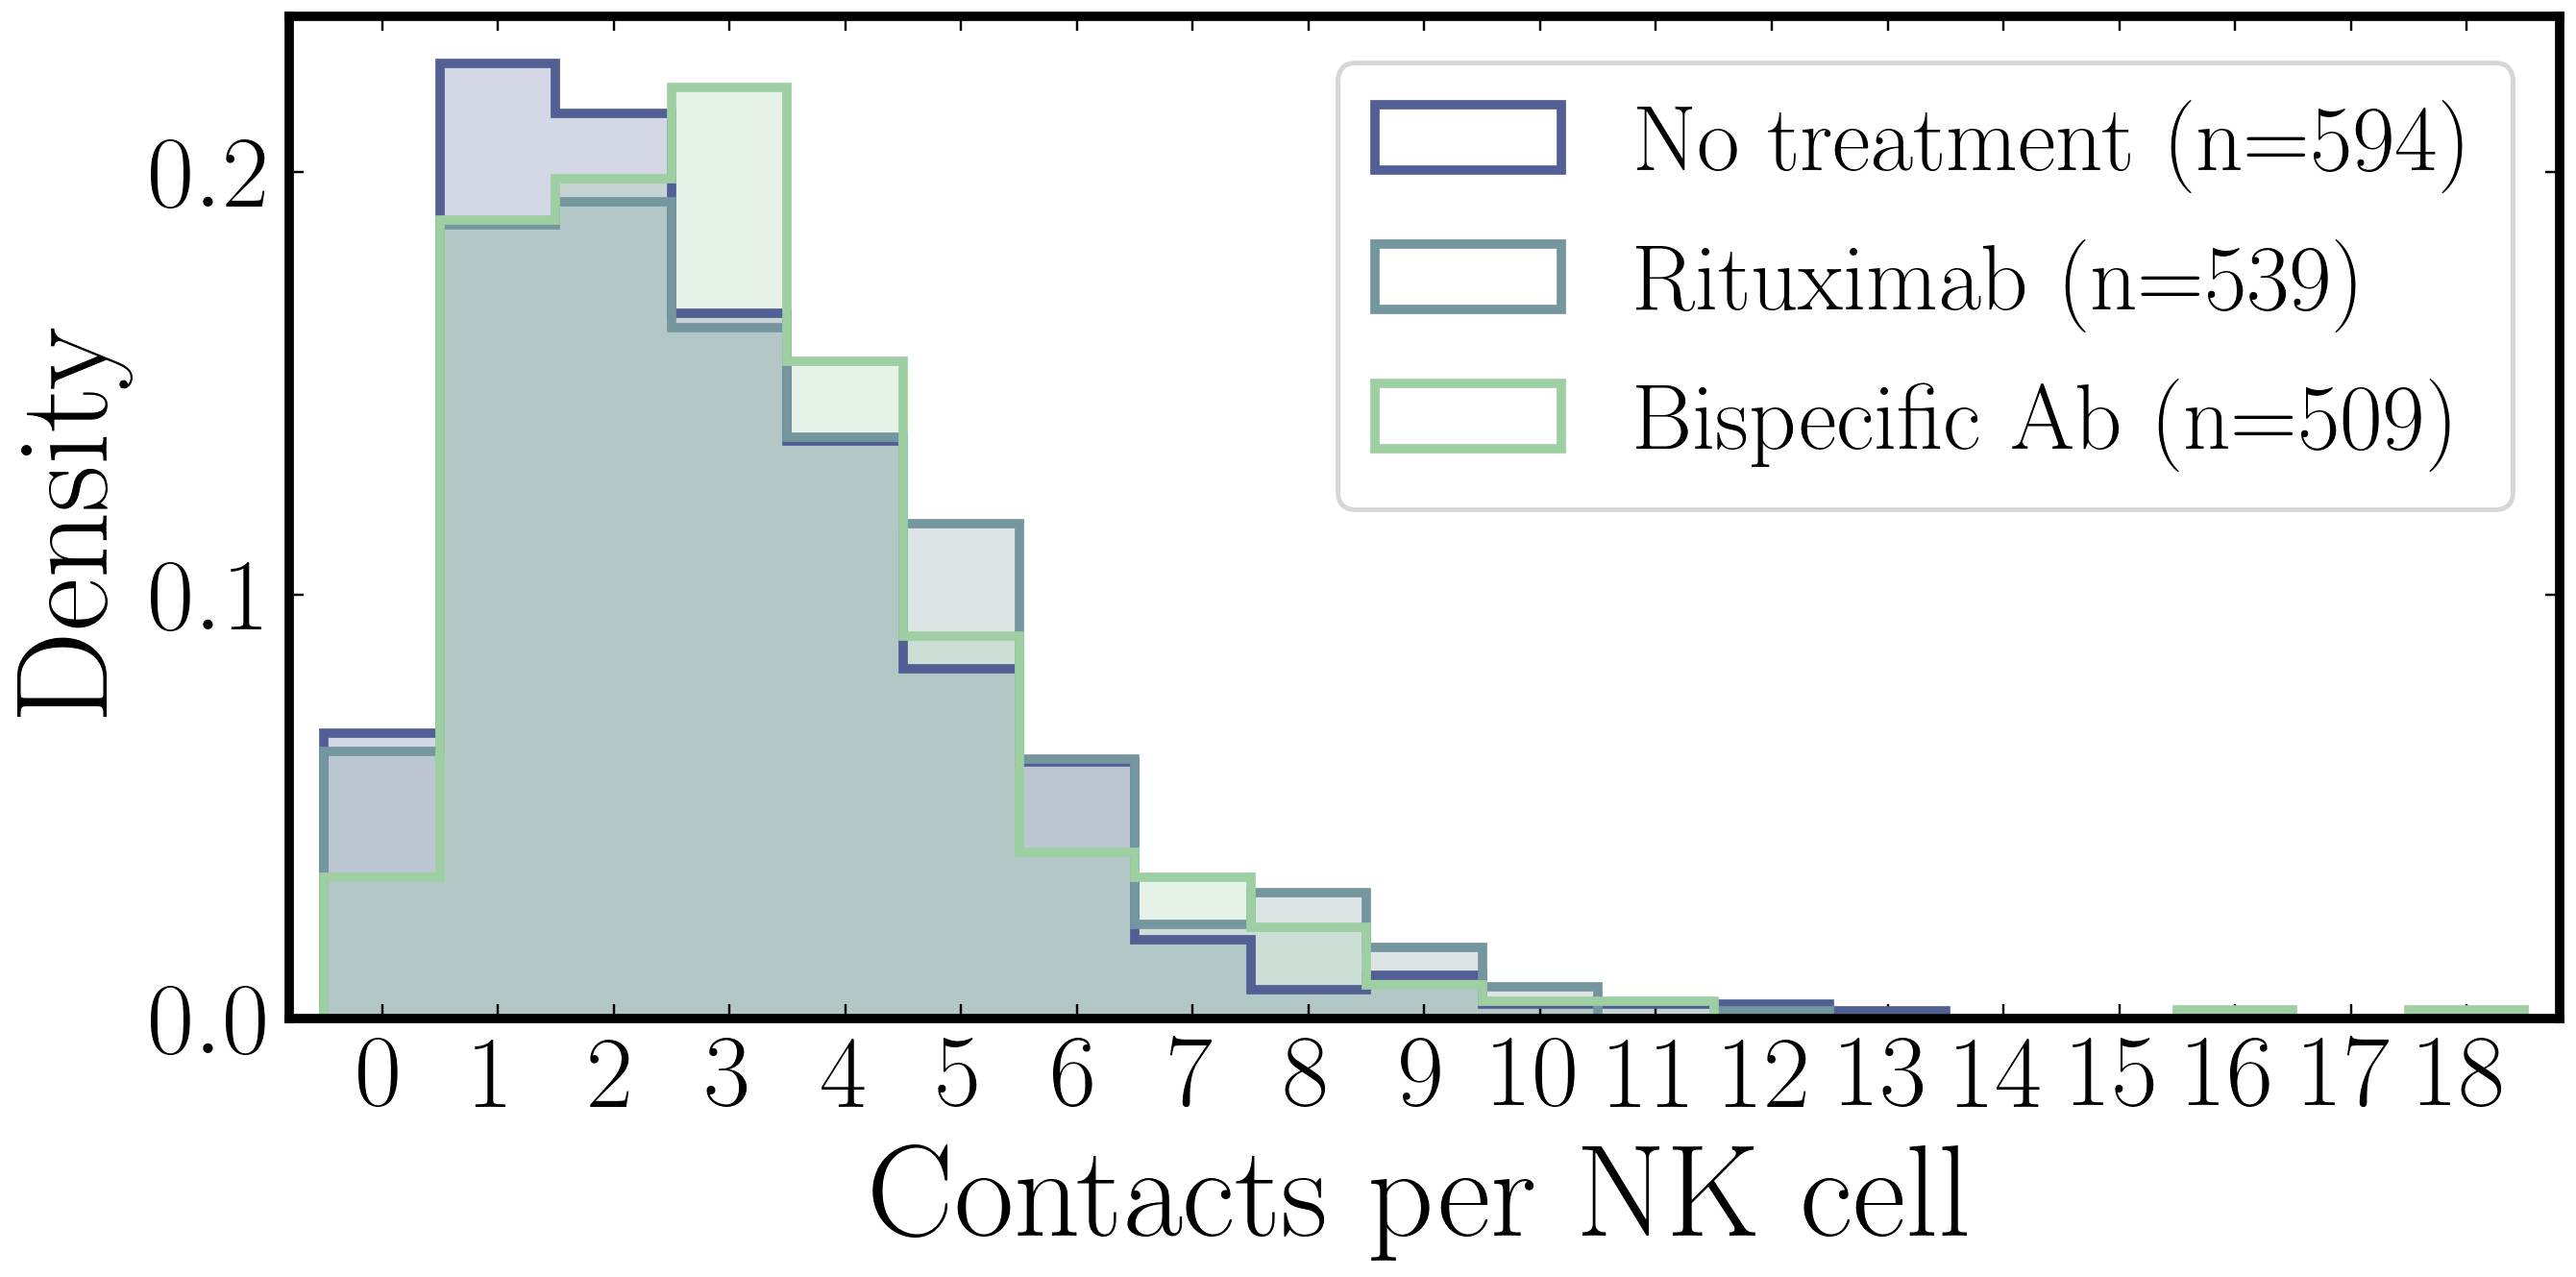

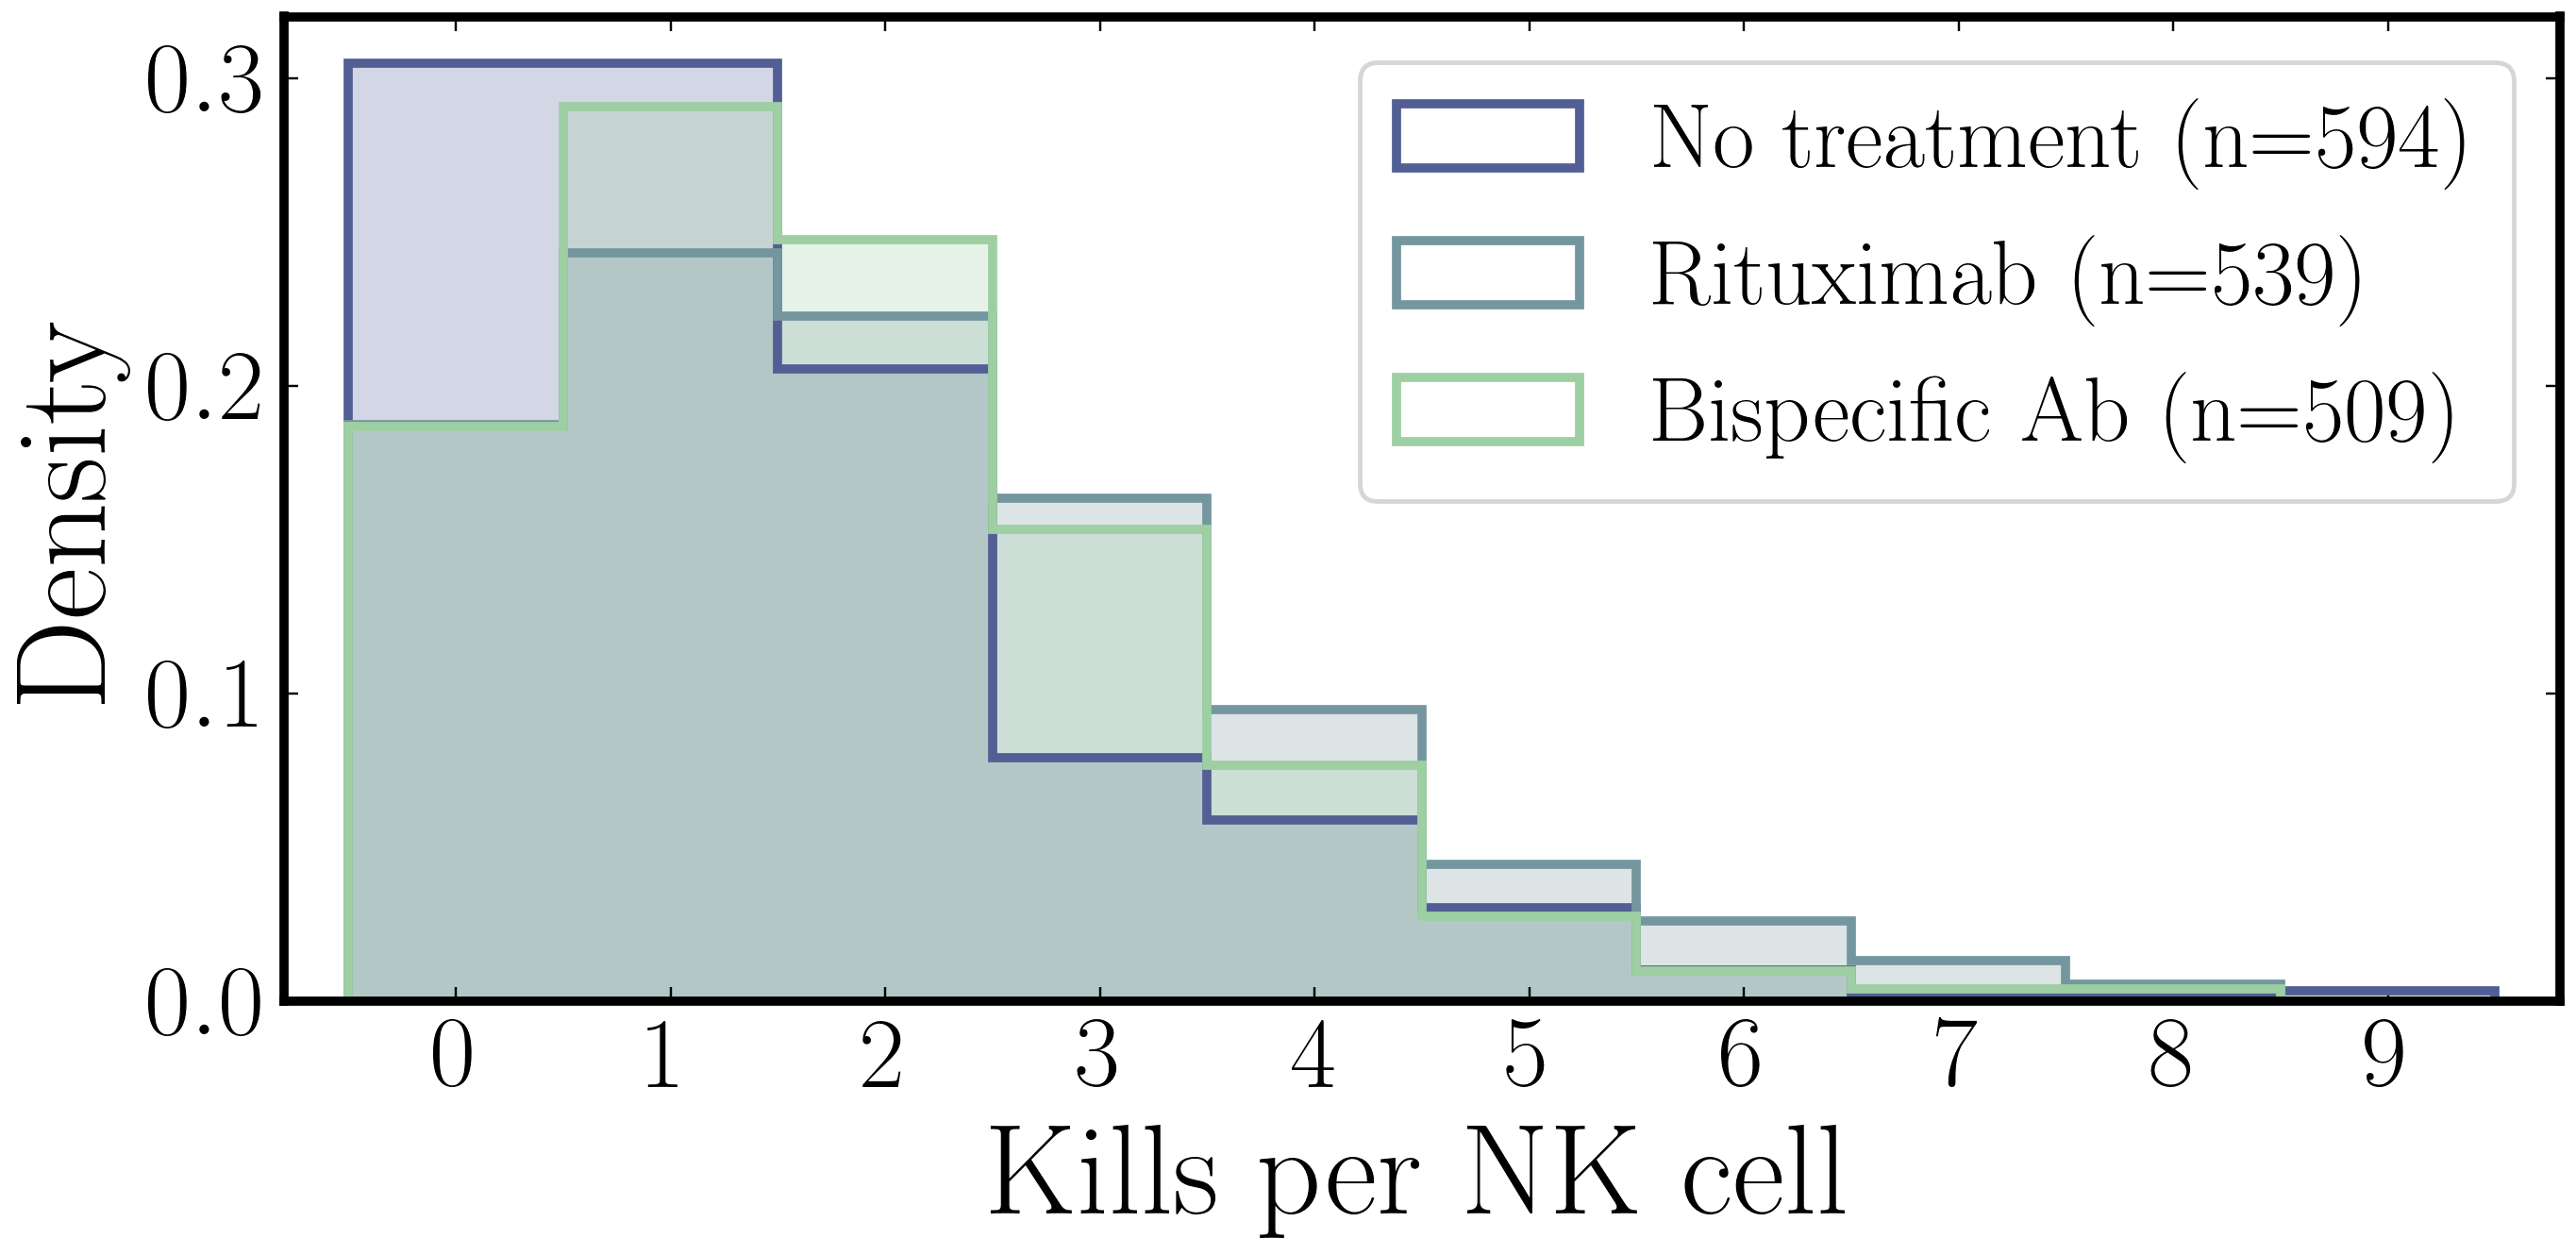

PosixPath('/Users/marsian/PhD_LifeSciRes/Orca/section_2/figures/analysis_1/kills_per_nk_cell.svg')

In [24]:
manual_colors = {
    "No treatment": "#515f95",  
    "Rituximab": "#74979f",     
    "Bispecific Ab": "#9dcfa3",  
}
def plot_count_distribution(datasets, labels, xlabel, colors, save_dir=FIGURE_ROOT):
    max_count = max(np.max(data) for data in datasets)
    bins = np.arange(-0.5, max_count + 1.5, 1)

    fig, ax = plt.subplots(figsize=(8, 4), dpi=350)

    for spine in ax.spines.values():
        spine.set_linewidth(2)

    for data, label in zip(datasets, labels):
        color = colors[label]
        legend_label = f"{label} (n={len(data)})"

        ax.hist(data, bins=bins, density=True, histtype="stepfilled", alpha=0.25, color=color)
        ax.hist(data, bins=bins, density=True, histtype="step", linewidth=2, color=color, label=legend_label)

    ax.set_xlim(-0.8, max_count + 0.8)
    ax.set_xticks(np.arange(0, max_count + 1, 1))
    ax.tick_params(axis="both", labelsize=22)
    ax.xaxis.set_minor_locator(NullLocator())
    ax.yaxis.set_minor_locator(NullLocator())

    ax.set_xlabel(xlabel, fontsize=28)
    ax.set_ylabel("Density", fontsize=28)
    ax.legend(frameon=True, fontsize=20)

    fig.tight_layout()

    save_dir.mkdir(parents=True, exist_ok=True)
    out_path = save_dir / f"{xlabel.replace(' ', '_').lower()}.svg"

    fig.savefig(out_path, format="svg", bbox_inches="tight", transparent=True)
    plt.show()

    return out_path

plot_count_distribution(
    contact_datasets,
    labels,
    "Contacts per NK cell",
    manual_colors,
)

plot_count_distribution(
    kill_datasets,
    labels,
    "Kills per NK cell",
    manual_colors,
)

## Bayesian inference

In [17]:
from section_1.src import inference as cih

MODEL_ORDER = ["homo", "Z2P", "Dis2P", "hetero3"]

INFERENCE_FUNCTIONS = {
    "homo": cih.inference_homo,
    "Z2P": cih.inference_Z2P,
    "Dis2P": cih.inference_Dis2P,
    "hetero3": cih.inference_hetero3,
}

OBS_TIME = 1.0
FORCE_RERUN = False

SMC_PARTICLES = 10000
CHAINS = 8
SMC_CORES = 6

LAMBDA_PRIOR_BOUNDS = (-5.0, 2.0)
P_PRIOR_BOUNDS = (1.0, 1.0)
STD_PRIOR_FACTOR = 5.0
SMC_THRESHOLD = 0.5
SMC_CORRELATION_THRESHOLD = 0.01

def slug(text: str) -> str:
    return str(text).lower().replace(" ", "_").replace("-", "_")


def save_idata(idata: az.InferenceData, out_path: Path) -> None:
    out_path.parent.mkdir(parents=True, exist_ok=True)
    tmp_path = out_path.with_name(f".{out_path.stem}.{os.getpid()}.tmp{out_path.suffix}")

    if tmp_path.exists():
        tmp_path.unlink()

    az.to_netcdf(idata, str(tmp_path))
    tmp_path.replace(out_path)


def run_or_load_inference(
    condition_label: str,
    outcome_name: str,
    counts: np.ndarray,
    model_name: str,
    model_index: int,
) -> az.InferenceData:
    out_dir = RESULT_ROOT / slug(condition_label) / slug(outcome_name)
    out_dir.mkdir(parents=True, exist_ok=True)

    posterior_path = out_dir / f"posterior_{model_name}_smc.nc"
    summary_path = out_dir / f"posterior_summary_{model_name}_smc.csv"
    logml_path = out_dir / f"log_marginal_likelihood_{model_name}_smc.csv"

    if posterior_path.exists() and logml_path.exists() and not FORCE_RERUN:
        return az.from_netcdf(str(posterior_path))

    fn = INFERENCE_FUNCTIONS[model_name]

    common_kwargs = dict(
        draws=SMC_PARTICLES,
        chains=CHAINS,
        cores=SMC_CORES,
        lambda_prior_bounds=LAMBDA_PRIOR_BOUNDS,
        random_seed= None,
        threshold=SMC_THRESHOLD,
        correlation_threshold=SMC_CORRELATION_THRESHOLD,
    )

    if model_name in {"Z2P", "hetero3"}:
        common_kwargs["p_prior_bounds"] = P_PRIOR_BOUNDS

    if model_name in {"Dis2P", "hetero3"}:
        common_kwargs["std_prior_factor"] = STD_PRIOR_FACTOR

    print(f"Running {condition_label} / {outcome_name} / {model_name}")

    pack = fn(counts, OBS_TIME, **common_kwargs)
    idata = pack["idata"]

    save_idata(idata, posterior_path)
    az.summary(idata).to_csv(summary_path)

    logml = cih.smc_log_evidence(idata)

    pd.DataFrame(
        [
            {
                "condition": condition_label,
                "outcome": outcome_name,
                "model": model_name,
                "logml": logml,
                "sampler": "smc",
                "chains": CHAINS,
                "smc_particles": SMC_PARTICLES,
            }
        ]
    ).to_csv(logml_path, index=False)

    return idata

def bayes_factor_pairs(logml_by_model: dict[str, float]) -> pd.DataFrame:
    rows = []

    for m1, m2 in combinations(MODEL_ORDER, 2):
        delta = float(logml_by_model[m1] - logml_by_model[m2])

        rows.append(
            {
                "model_1": m1,
                "model_2": m2,
                "logml_1": float(logml_by_model[m1]),
                "logml_2": float(logml_by_model[m2]),
                "delta_logml": delta,
                "log10_BF": delta / np.log(10.0),
                "BF": float(np.exp(delta)) if delta < 709 else np.inf,
            }
        )

    return pd.DataFrame(rows).sort_values("delta_logml", ascending=False).reset_index(drop=True)

In [18]:
count_datasets = {
    "No treatment": {
        "contacts": nt_contacts,
        "kills": nt_kills,
    },
    "Rituximab": {
        "contacts": rtx_contacts,
        "kills": rtx_kills,
    },
    "Bispecific Ab": {
        "contacts": bispecific_contacts,
        "kills": bispecific_kills,
    },
}

posterior_data = {}
logml_rows = []
bf_tables = {}

for condition_label, outcomes in count_datasets.items():
    for outcome_name, counts in outcomes.items():
        logml_by_model = {}

        for model_index, model_name in enumerate(MODEL_ORDER):
            idata = run_or_load_inference(
                condition_label=condition_label,
                outcome_name=outcome_name,
                counts=np.asarray(counts, dtype=int),
                model_name=model_name,
                model_index=model_index,
            )

            posterior_data[(condition_label, outcome_name, model_name)] = idata

            logml = cih.smc_log_evidence(idata)
            logml_by_model[model_name] = logml

            logml_rows.append(
                {
                    "condition": condition_label,
                    "outcome": outcome_name,
                    "model": model_name,
                    "logml": logml,
                }
            )

        bf = bayes_factor_pairs(logml_by_model)
        bf_tables[(condition_label, outcome_name)] = bf

        out_dir = RESULT_ROOT / slug(condition_label) / slug(outcome_name)
        bf.to_csv(out_dir / "bayes_factors_pairs_smc.csv", index=False)

logml_df = pd.DataFrame(logml_rows)
logml_df.to_csv(RESULT_ROOT / "log_marginal_likelihoods_all_conditions_smc.csv", index=False)

logml_df.sort_values(
    ["condition", "outcome", "logml"],
    ascending=[True, True, False],
)

,condition,outcome,model,logml
18,Bispecific Ab,contacts,Dis2P,-1056.559279
19,Bispecific Ab,contacts,hetero3,-1062.239871
16,Bispecific Ab,contacts,homo,-1069.806650
17,Bispecific Ab,contacts,Z2P,-1074.837607
22,Bispecific Ab,kills,Dis2P,-869.801359
20,Bispecific Ab,kills,homo,-869.923837
21,Bispecific Ab,kills,Z2P,-871.301809
23,Bispecific Ab,kills,hetero3,-872.773527
2,No treatment,contacts,Dis2P,-1217.721746
3,No treatment,contacts,hetero3,-1222.978656


In [19]:
MODEL_DISPLAY = {
    "homo": "homo",
    "Z2P": "ZI",
    "Dis2P": r"$\Gamma$",
    "hetero3": r"ZI-$\Gamma$",
}

MODEL_COLORS = {
    "homo": "#9BD7FF",
    "Z2P": "#56B4E9",
    "Dis2P": "#2F80ED",
    "hetero3": "#0B1F5B",
}

CONDITION_ORDER = ["No treatment", "Rituximab", "Bispecific Ab"]
OUTCOME_ORDER = ["contacts", "kills"]


def add_bayes_factor_vs_best(logml_df: pd.DataFrame) -> pd.DataFrame:
    df = logml_df.copy()

    df["best_logml"] = df.groupby(["condition", "outcome"])["logml"].transform("max")
    df["delta_logml_vs_best"] = df["logml"] - df["best_logml"]
    df["log10_BF_model_vs_best"] = df["delta_logml_vs_best"] / np.log(10.0)
    df["log10_BF_best_vs_model"] = -df["log10_BF_model_vs_best"]
    df["BF_best_vs_model"] = np.exp(
        np.clip(-df["delta_logml_vs_best"], -745, 709)
    )

    best_models = (
        df.sort_values("logml", ascending=False)
        .groupby(["condition", "outcome"])["model"]
        .first()
        .rename("best_model")
        .reset_index()
    )

    df = df.merge(best_models, on=["condition", "outcome"], how="left")
    df["model_display"] = df["model"].map(MODEL_DISPLAY).fillna(df["model"])

    return df


def overall_model_comparison(logml_df: pd.DataFrame) -> pd.DataFrame:
    df = (
        logml_df
        .groupby(["outcome", "model"], as_index=False)["logml"]
        .sum()
        .rename(columns={"logml": "total_log_evidence"})
    )

    df["best_total_log_evidence"] = df.groupby("outcome")["total_log_evidence"].transform("max")
    df["delta_log_evidence_vs_best"] = df["total_log_evidence"] - df["best_total_log_evidence"]
    df["log10_BF_model_vs_best"] = df["delta_log_evidence_vs_best"] / np.log(10.0)
    df["log10_BF_best_vs_model"] = -df["log10_BF_model_vs_best"]
    df["BF_best_vs_model"] = np.exp(
        np.clip(-df["delta_log_evidence_vs_best"], -745, 709)
    )
    df["model_display"] = df["model"].map(MODEL_DISPLAY).fillna(df["model"])

    return df.sort_values(
        ["outcome", "total_log_evidence"],
        ascending=[True, False],
    ).reset_index(drop=True)


bf_condition_df = add_bayes_factor_vs_best(logml_df)
overall_df = overall_model_comparison(logml_df)

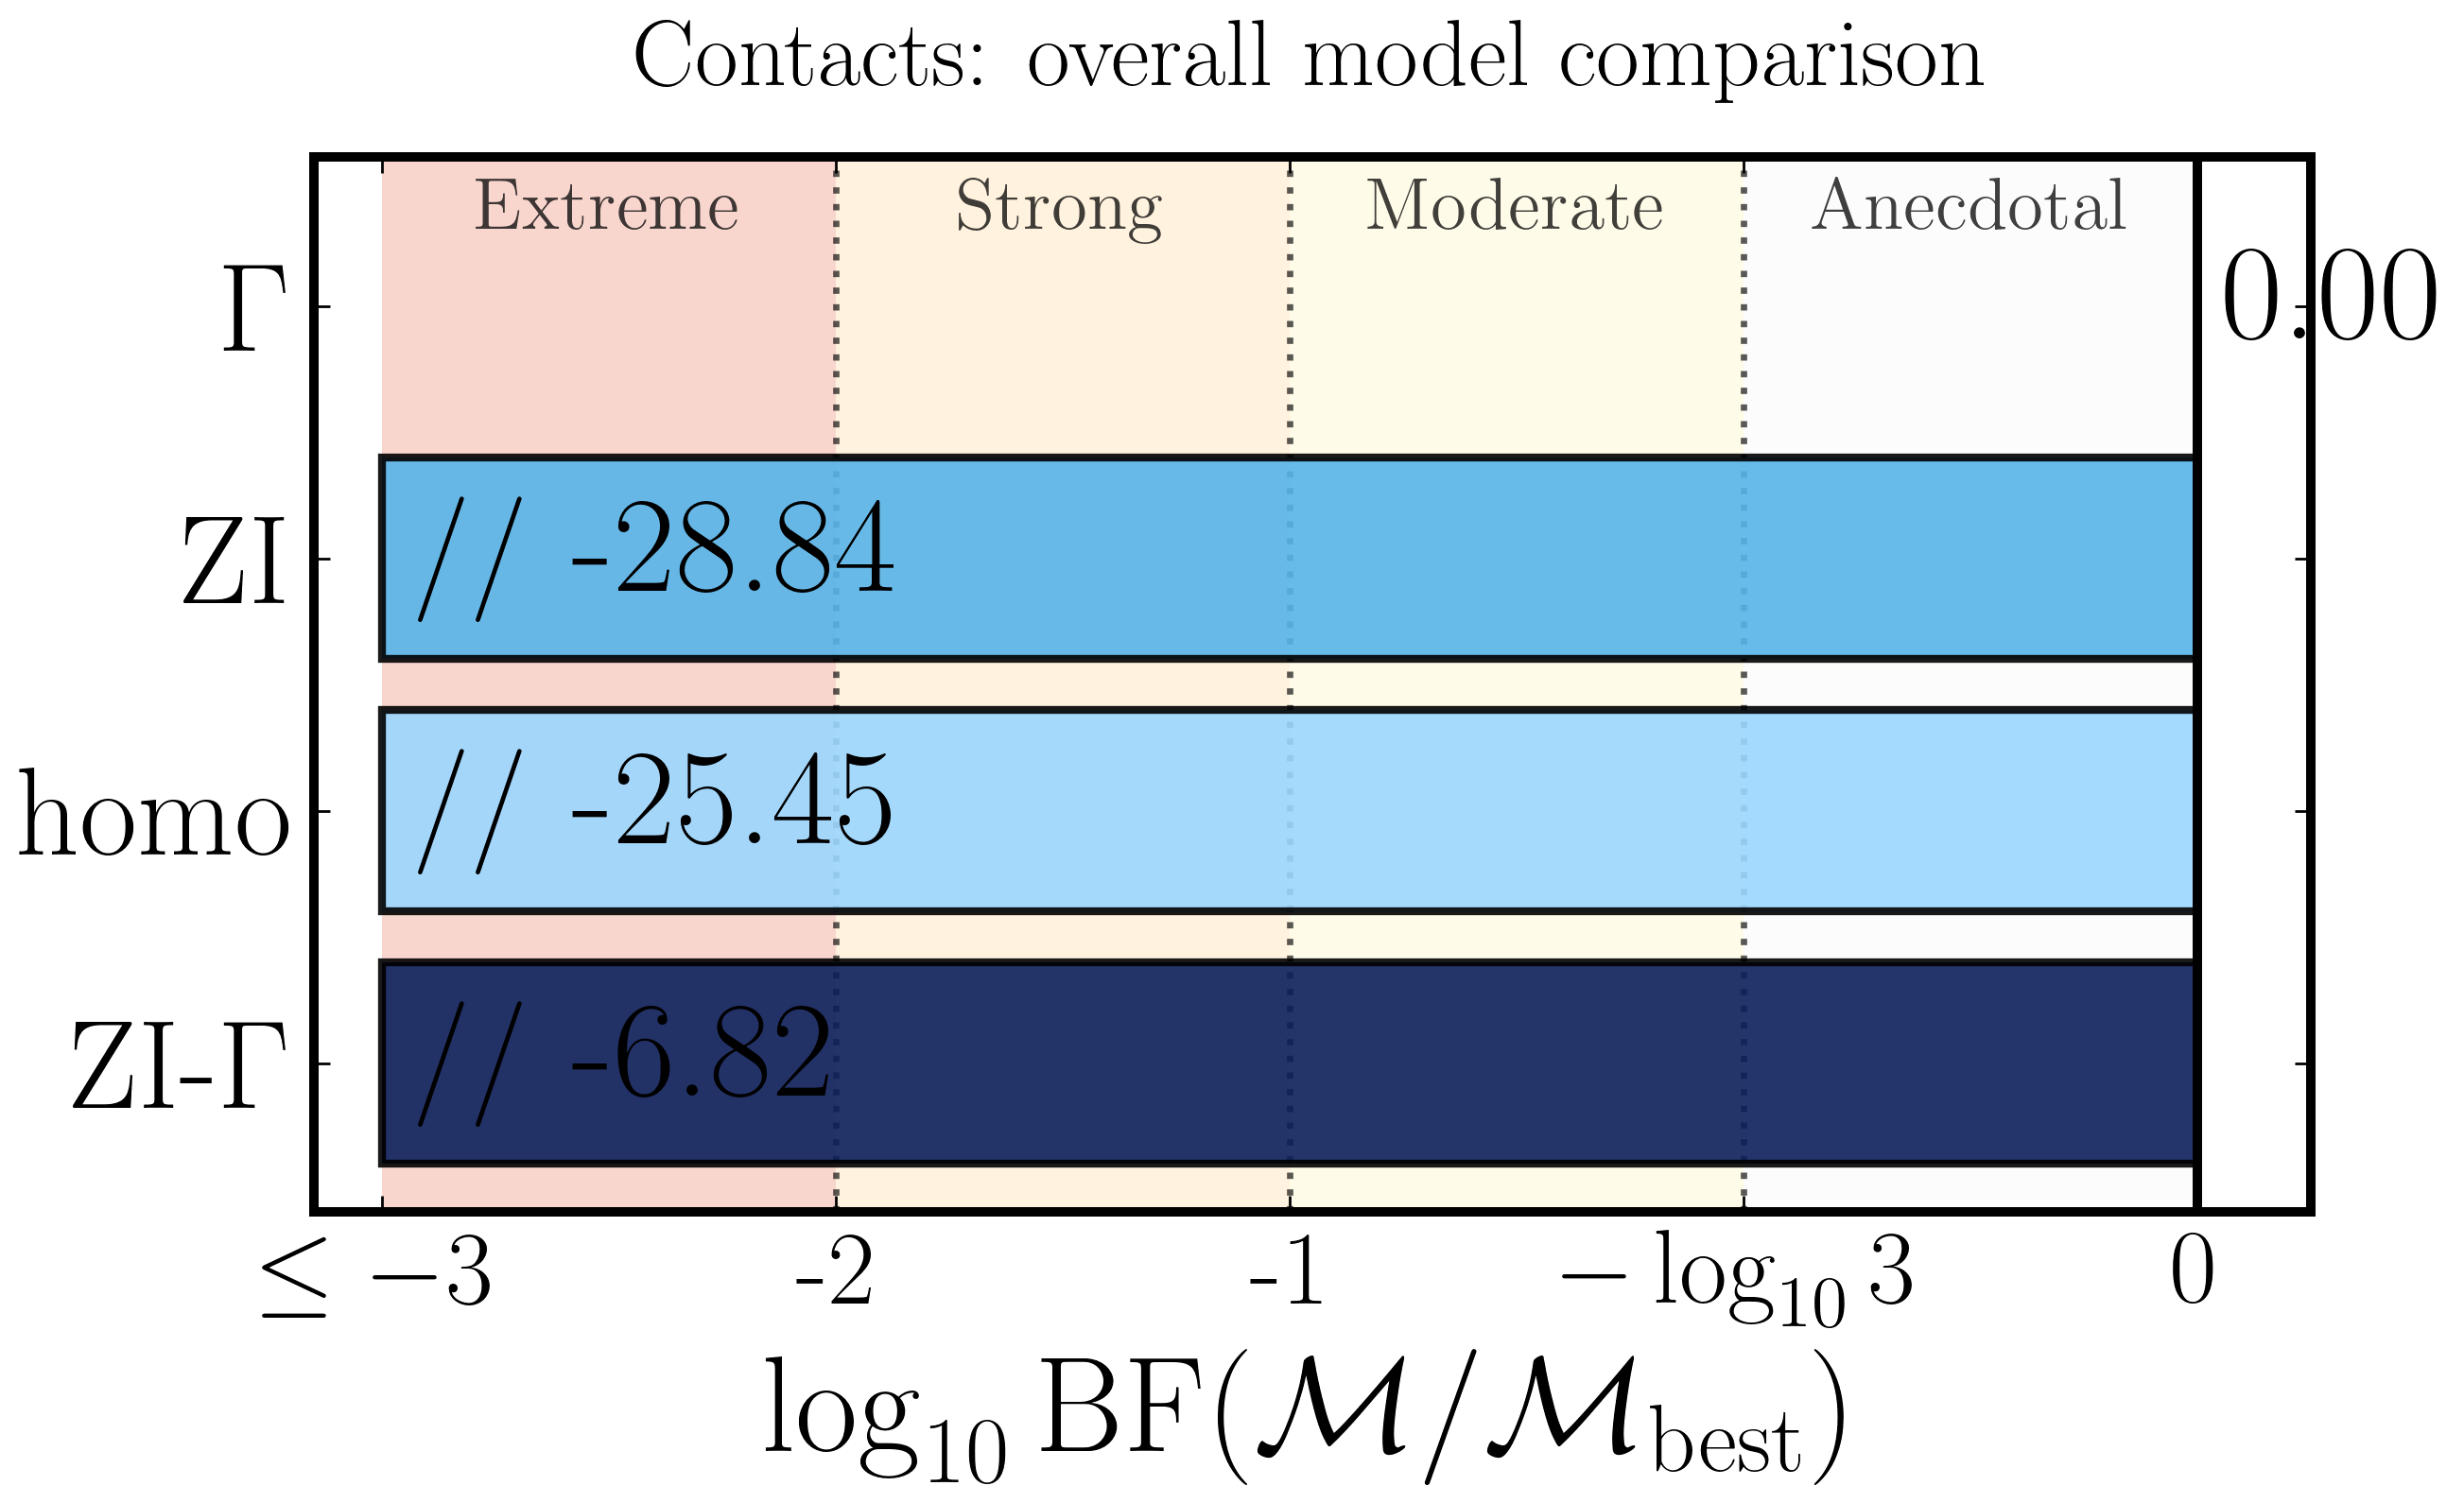

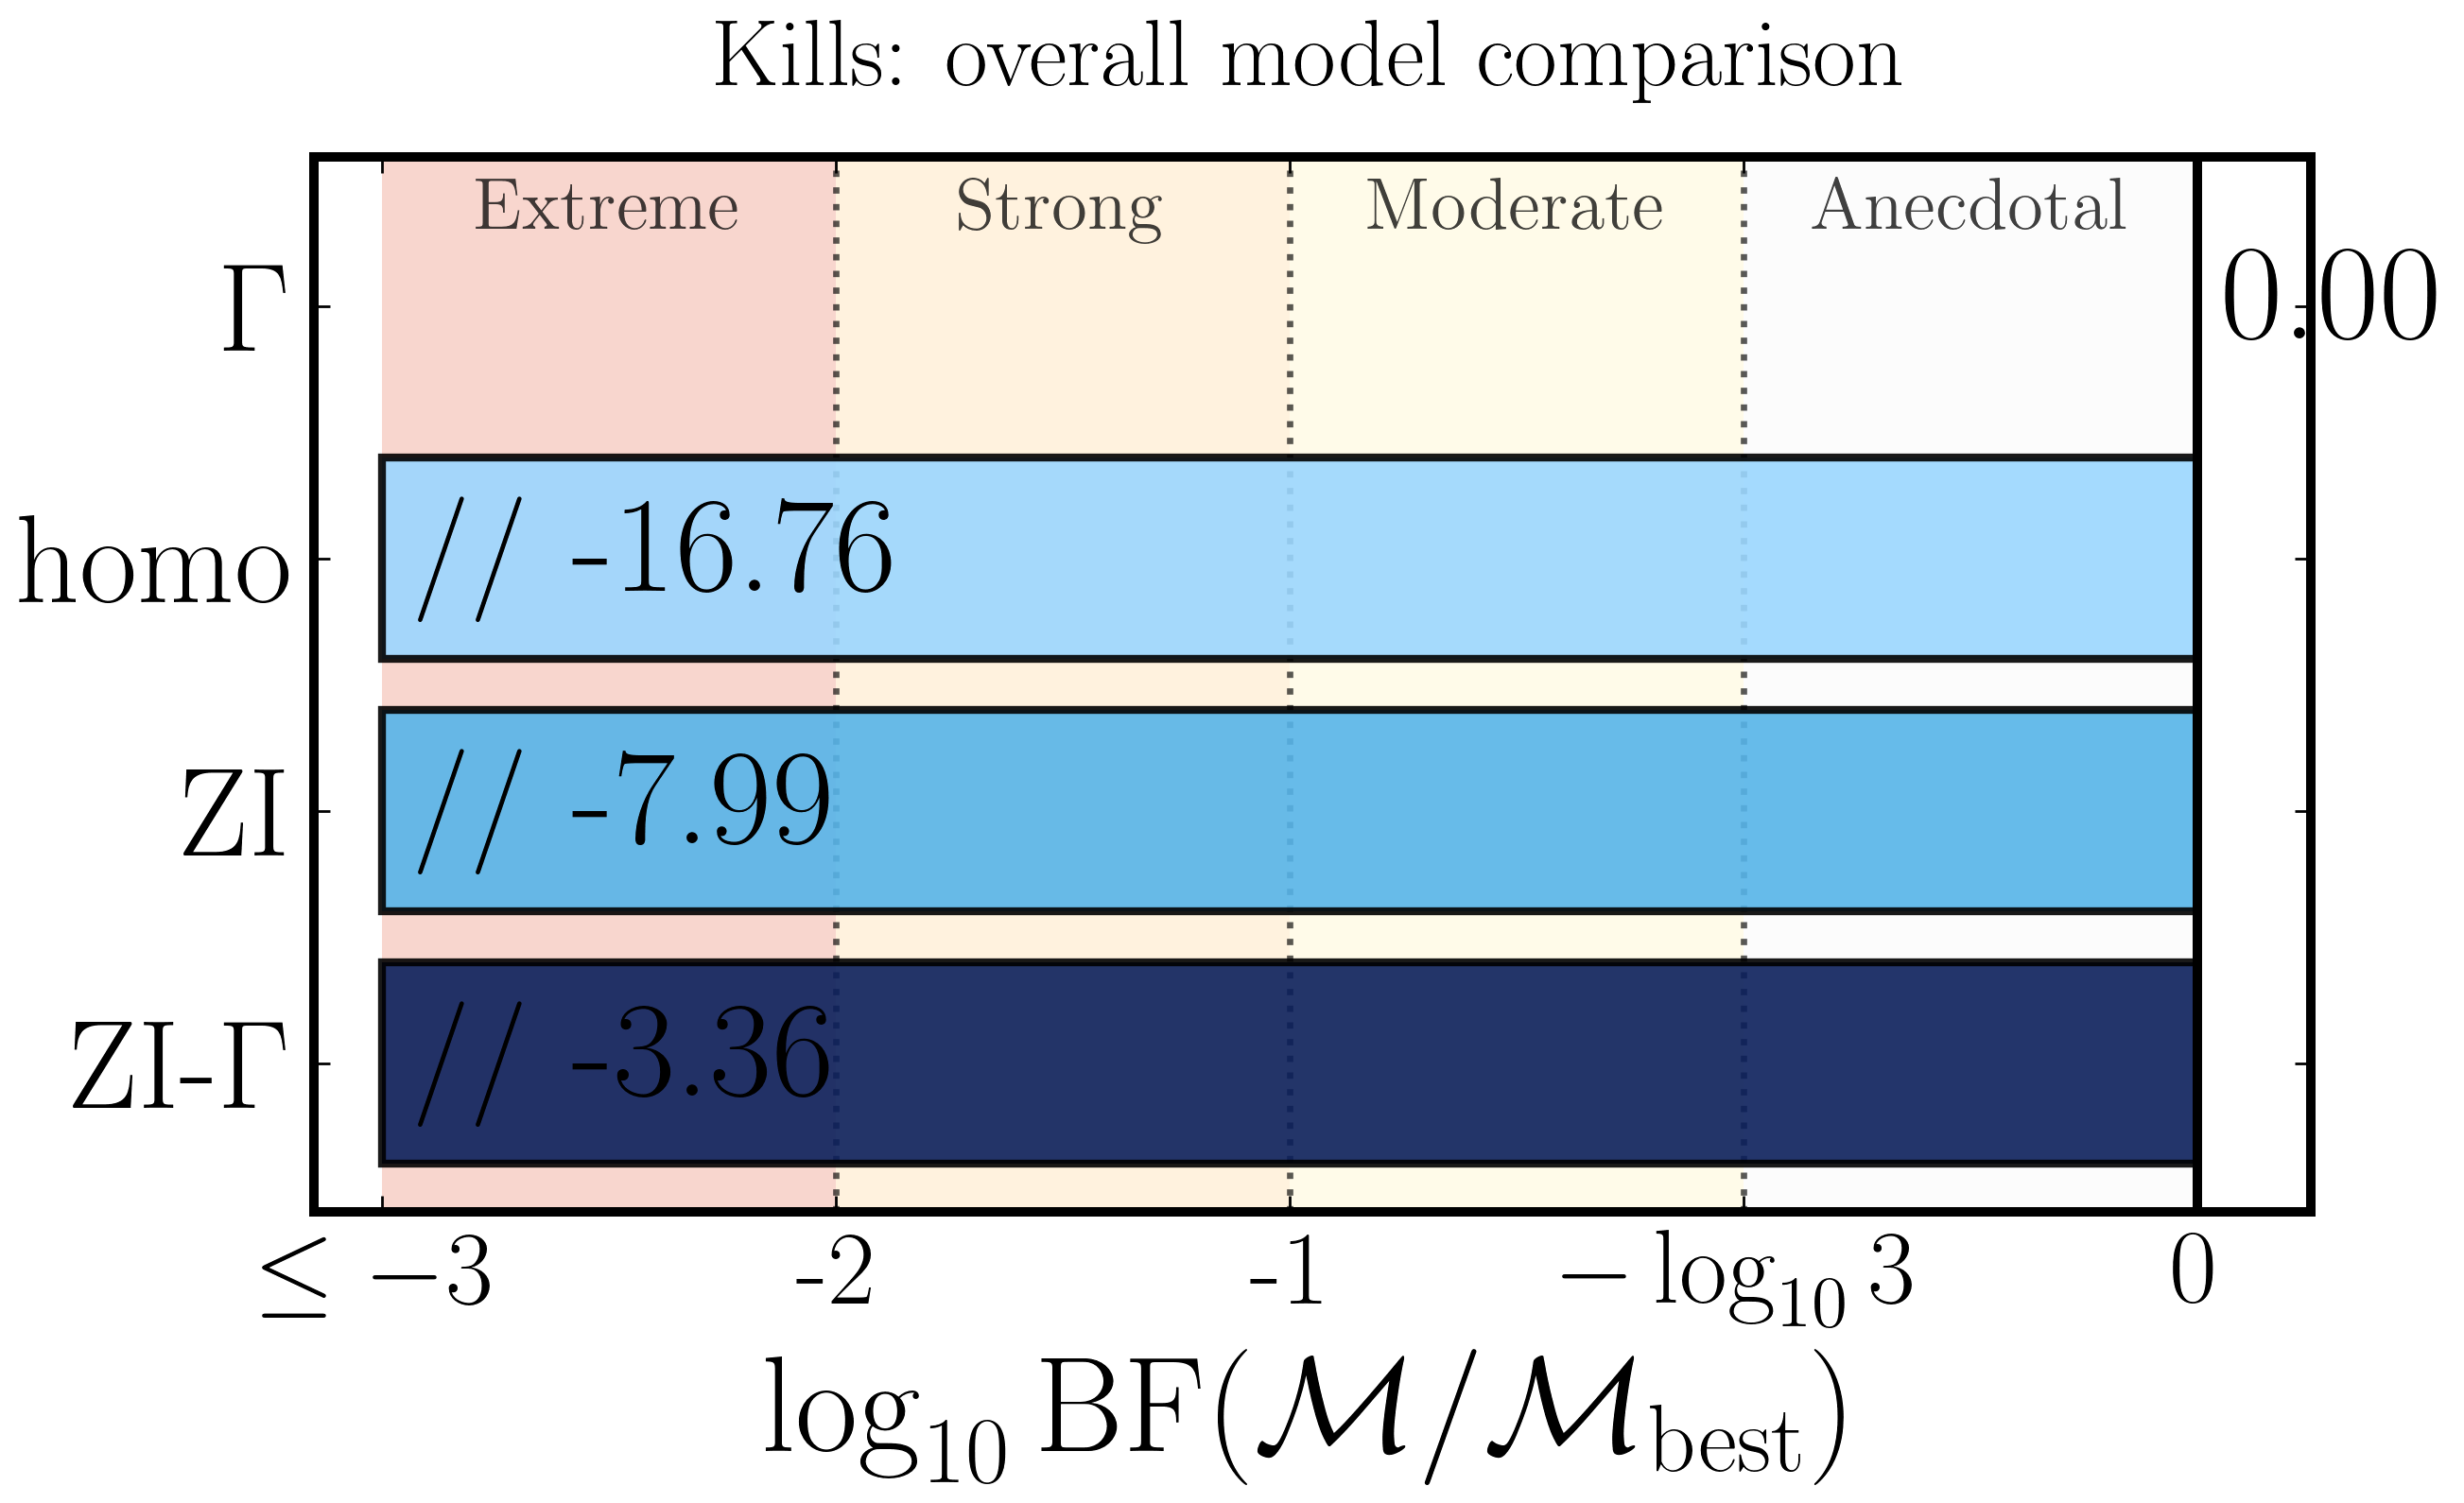

,svg
0,/Users/marsian/PhD_LifeSciRes/Orca/section_2/f...
1,/Users/marsian/PhD_LifeSciRes/Orca/section_2/f...


In [20]:
def _to_banded_bf_axis(
    log10_bf_model_vs_best,
    *,
    clip_log10_evidence: float = 3.0,
):
    """
    Convert raw log10 BF(M / M_best) onto an equal-width visual axis.

    Display bands:
        0 to -1:   anecdotal, BF_best/model < 3
        -1 to -2:   moderate,   3 to 10
        -2 to -3:   strong,     10 to 100
        -3 to -4:   extreme,    >100

    Values beyond clip_log10_evidence are clipped visually.
    The original values should still be printed as text labels.
    """
    value = np.asarray(log10_bf_model_vs_best, dtype=float)
    evidence = np.maximum(-value, 0.0)

    bf3 = np.log10(3.0)
    bf10 = 1.0
    bf100 = 2.0
    clip_log10_evidence = max(float(clip_log10_evidence), bf100 + 1e-6)

    display = np.zeros_like(evidence, dtype=float)

    mask = evidence <= bf3
    display[mask] = evidence[mask] / bf3

    mask = (evidence > bf3) & (evidence <= bf10)
    display[mask] = 1.0 + (evidence[mask] - bf3) / (bf10 - bf3)

    mask = (evidence > bf10) & (evidence <= bf100)
    display[mask] = 2.0 + (evidence[mask] - bf10) / (bf100 - bf10)

    mask = evidence > bf100
    display[mask] = 3.0 + np.minimum(
        (evidence[mask] - bf100) / (clip_log10_evidence - bf100),
        1.0,
    )

    return -display


def plot_overall_bayes_factors(
    overall_df: pd.DataFrame,
    outcome: str,
    *,
    save_path: Path | None = None,
    dpi: int = 400,
    colors: dict[str, str] = MODEL_COLORS,
    band_colors: dict[str, str] | None = None,
    band_alpha: float = 0.28,
    clip_log10_evidence: float = 3.0,
) -> Path | None:
    if band_colors is None:
        band_colors = {
            "anecdotal": "#F7F7F7",
            "moderate": "#FFF3B0",
            "strong": "#FFD28A",
            "extreme": "#E76F51",
        }

    plot_df = (
        overall_df[overall_df["outcome"] == outcome]
        .copy()
        .sort_values("total_log_evidence", ascending=False)
    )

    best_model = str(plot_df.iloc[0]["model"])
    plot_df["x_plot"] = _to_banded_bf_axis(
        plot_df["log10_BF_model_vs_best"].to_numpy(),
        clip_log10_evidence=clip_log10_evidence,
    )
    plot_df["is_clipped"] = (
        -plot_df["log10_BF_model_vs_best"] > clip_log10_evidence
    )
    plot_df = plot_df.sort_values("x_plot", ascending=True)

    bar_colors = [
        "#000000" if model == best_model else colors.get(model, "black")
        for model in plot_df["model"]
    ]

    fig, ax = plt.subplots(figsize=(8.8, 4.5), dpi=dpi)

    xleft = -4.15
    xright = 0.25
    ax.set_xlim(xleft, xright)

    bands = [
        ("extreme", -4.0, -3.0),
        ("strong", -3.0, -2.0),
        ("moderate", -2.0, -1.0),
        ("anecdotal", -1.0, 0.0),
    ]

    for label, left, right in bands:
        ax.axvspan(
            left,
            right,
            color=band_colors.get(label, "white"),
            alpha=band_alpha,
            linewidth=0,
            zorder=0,
        )
        ax.text(
            (left + right) / 2,
            0.98,
            label.capitalize(),
            transform=ax.get_xaxis_transform(),
            ha="center",
            va="top",
            fontsize=14,
            color="black",
            alpha=0.75,
            zorder=1,
        )

    for threshold in [-1.0, -2.0, -3.0]:
        ax.axvline(
            threshold,
            color="black",
            linestyle=":",
            linewidth=1.2,
            alpha=0.65,
            zorder=2,
        )

    bars = ax.barh(
        plot_df["model_display"],
        plot_df["x_plot"],
        color=bar_colors,
        alpha=0.9,
        edgecolor="black",
        linewidth=1.5,
        zorder=3,
    )

    ax.axvline(0, color="black", linewidth=1.8, zorder=4)

    for bar, raw_value, x_plot, is_clipped in zip(
        bars,
        plot_df["log10_BF_model_vs_best"],
        plot_df["x_plot"],
        plot_df["is_clipped"],
    ):
        y = bar.get_y() + bar.get_height() / 2

        if is_clipped:
            ax.text(
                x_plot + 0.08,
                y,
                "//",
                va="center",
                ha="left",
                fontsize=24,
                color="black",
                zorder=5,
            )
            text_x = x_plot + 0.42
        elif x_plot < -0.3:
            text_x = x_plot + 0.12
        else:
            text_x = 0.06

        ax.text(
            text_x,
            y,
            f"{raw_value:.2f}",
            va="center",
            ha="left",
            fontsize=26,
            color="black",
            zorder=5,
        )

    ax.set_xticks([0, -1, -2, -3, -4])
    ax.set_xticklabels(
        [
            "0",
            r"$-\log_{10}3$",
            "-1",
            "-2",
            rf"$\leq -{clip_log10_evidence:g}$",
        ]
    )

    ax.set_xlabel(
        r"$\log_{10}\mathrm{BF}(\mathcal{M}/\mathcal{M}_{\mathrm{best}})$",
        fontsize=26,
    )
    ax.set_title(f"{outcome.capitalize()}: overall model comparison", fontsize=18, pad=14)

    ax.tick_params(axis="x", which="major", labelsize=20)
    ax.tick_params(axis="y", which="major", labelsize=24)
    ax.minorticks_off()
    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.8)
        spine.set_color("black")

    fig.subplots_adjust(left=0.30, bottom=0.26)

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(
            save_path,
            format="svg",
            bbox_inches="tight",
            pad_inches=0.2,
            transparent=True,
        )

    plt.show()

    return save_path


bayes_factor_overall_svg_paths = []

for outcome in OUTCOME_ORDER:
    bayes_factor_overall_svg_paths.append(
        plot_overall_bayes_factors(
            overall_df,
            outcome,
            save_path=FIGURE_ROOT / f"bayes_factor_overall_{outcome}.svg",
            colors=MODEL_COLORS,
            band_colors={
                "anecdotal": "#F7F7F7",
                "moderate": "#FFF3B0",
                "strong": "#FFD28A",
                "extreme": "#E76F51",
            },
            band_alpha=0.28,
            clip_log10_evidence=3.0,
        )
    )

pd.DataFrame({"svg": [str(path) for path in bayes_factor_overall_svg_paths]})

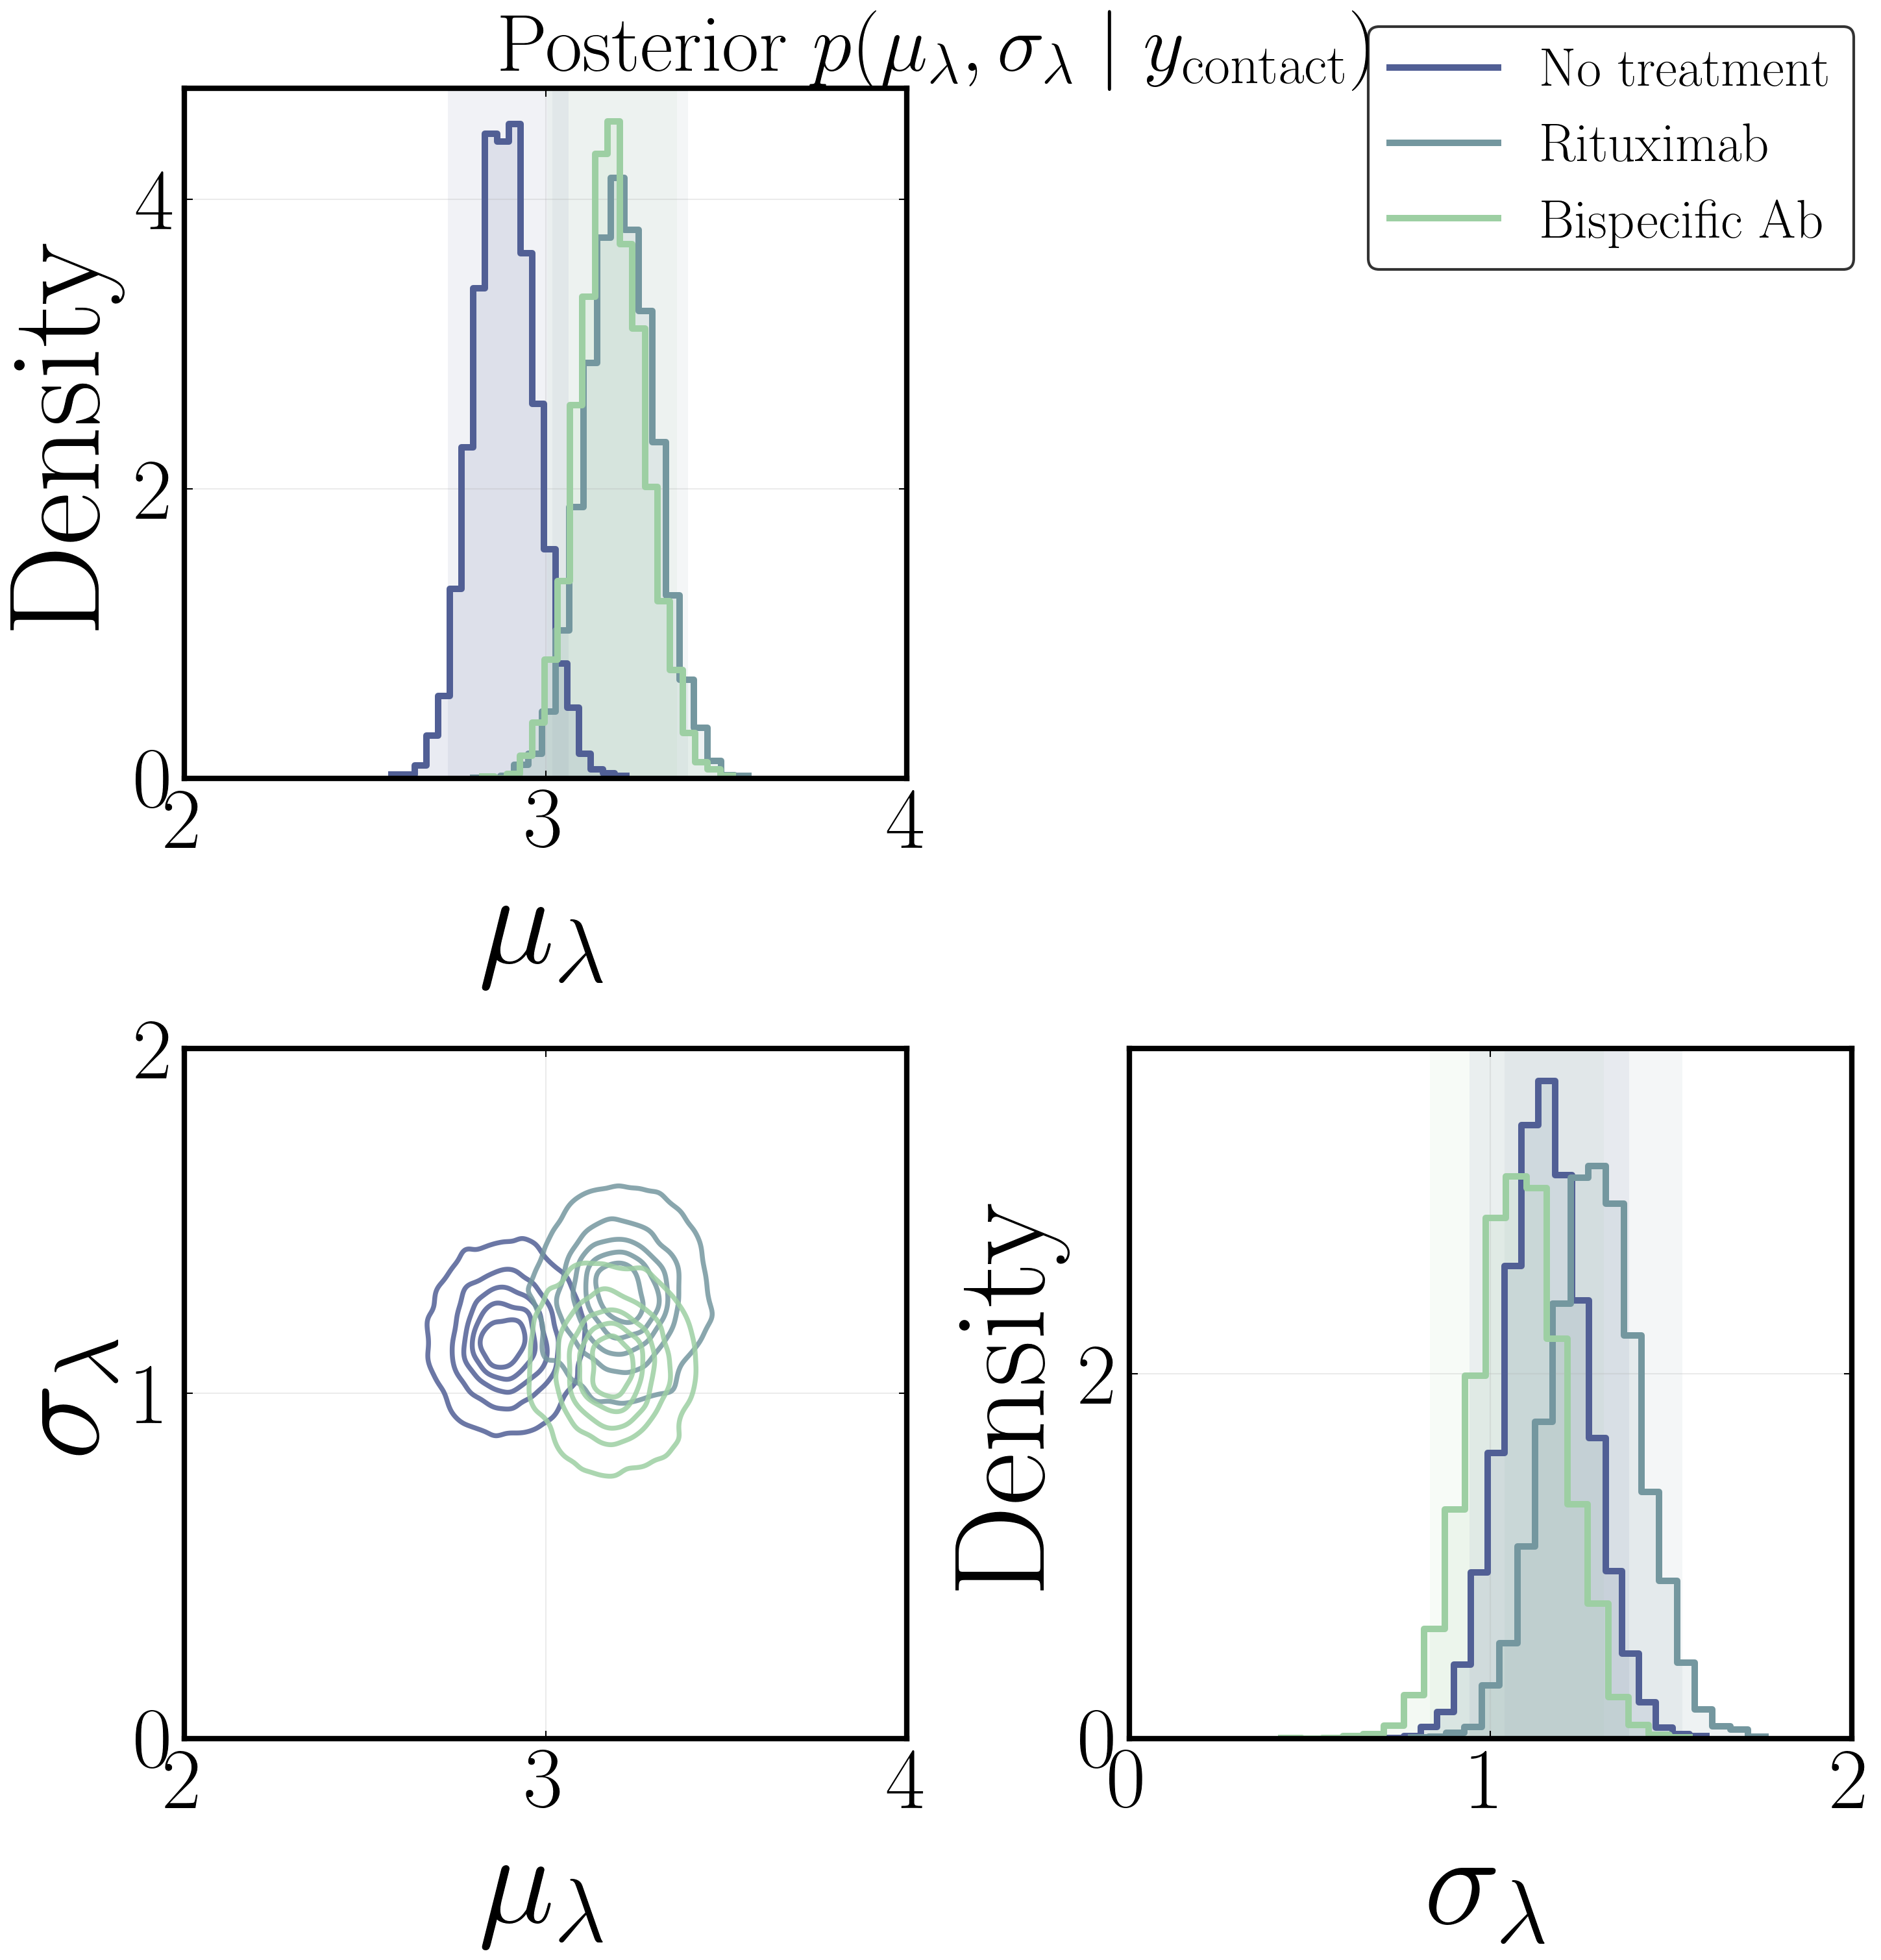

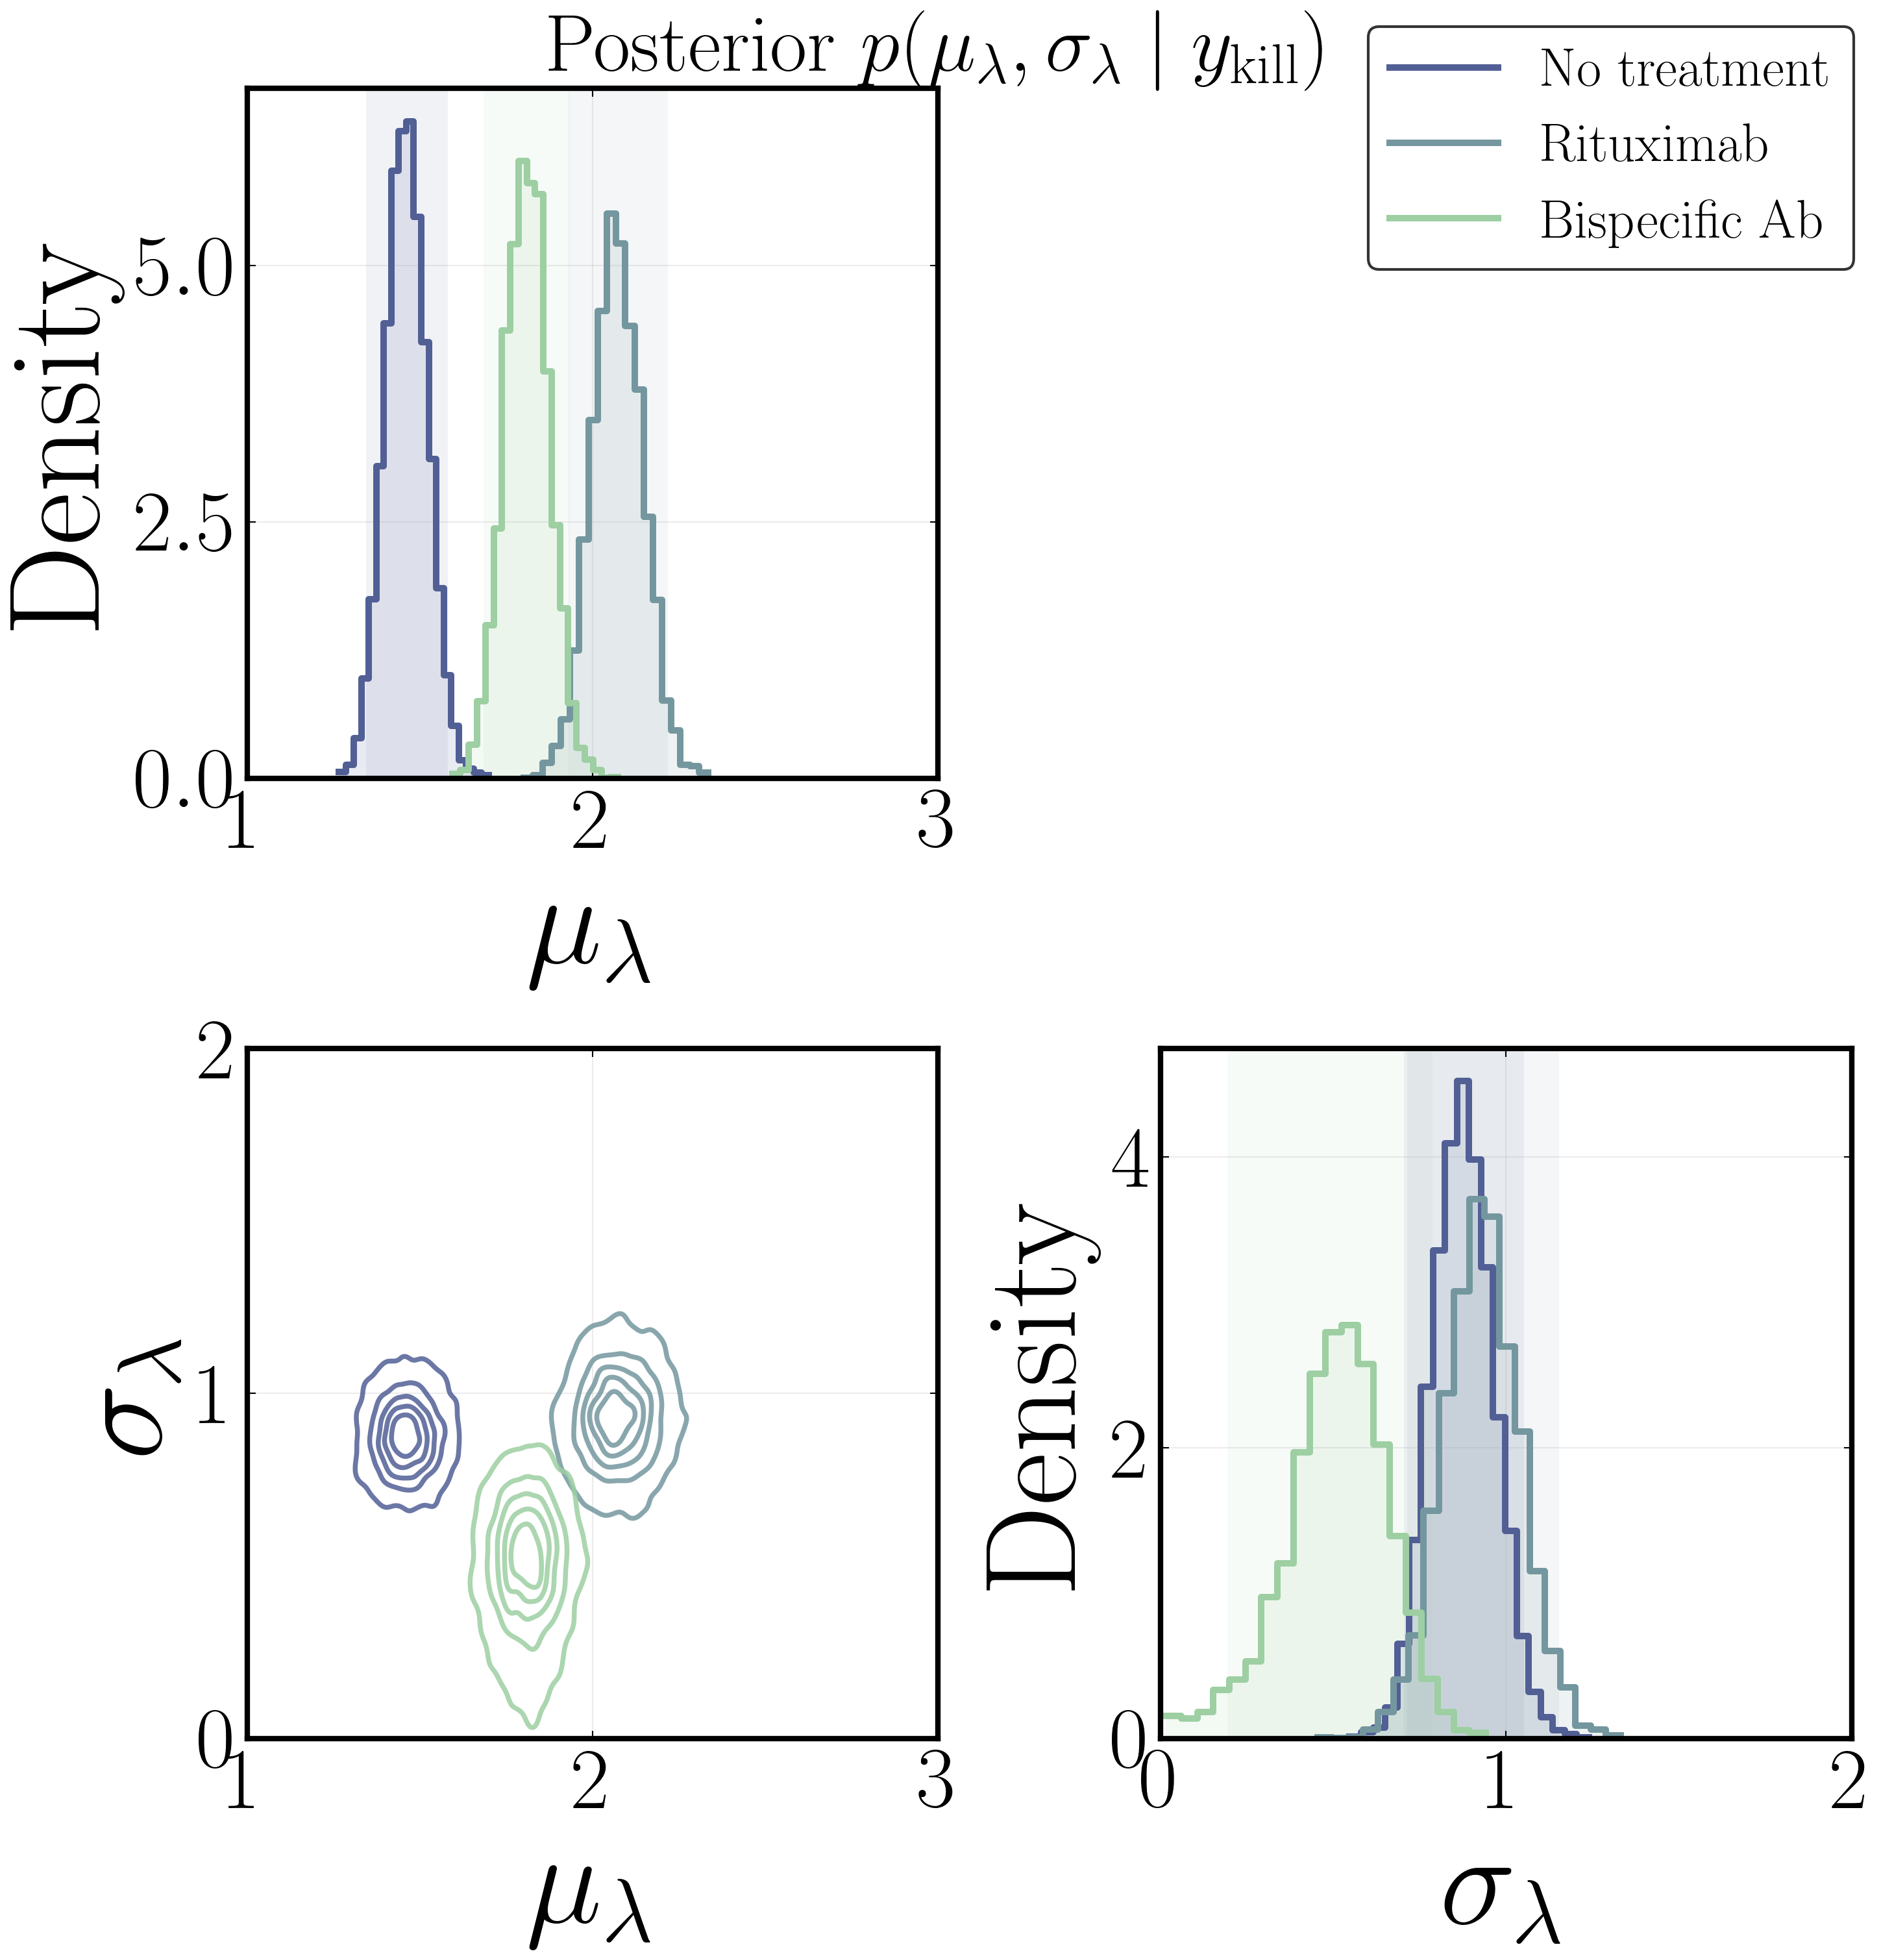

PosixPath('/Users/marsian/PhD_LifeSciRes/Orca/section_2/figures/analysis_1/gamma_posterior_three_conditions_kills.svg')

In [27]:
PARAM_DISPLAY = {
    "mu_lambda": r"$\mu_\lambda$",
    "sigma_lambda": r"$\sigma_\lambda$",
}

GAMMA_PARAMS = ["mu_lambda", "sigma_lambda"]

def get_posterior_samples(
    idata: az.InferenceData,
    param: str,
    *,
    sample_size: int = 6000,
    seed: int | None = None,
) -> np.ndarray:
    values = idata.posterior[param].stack(sample=("chain", "draw")).values.ravel()
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if sample_size is not None and values.size > sample_size:
        rng = np.random.default_rng(seed)
        values = values[rng.choice(values.size, sample_size, replace=False)]

    return values

def plot_gamma_posteriors_three_conditions(
    posterior_data: dict,
    outcome: str,
    *,
    model_name: str = "Dis2P",
    conditions: list[str] = ["No treatment", "Rituximab", "Bispecific Ab"],
    colors: dict[str, str] = manual_colors,
    parameters: list[str] = GAMMA_PARAMS,
    sample_size: int = 6000,
    hdi_prob: float = 0.95,
    bins: int = 20,
    param_limits: dict[str, tuple[float, float]] | None = None,
    save_dir: Path = FIGURE_ROOT,
    dpi: int = 300,
) -> Path:
    samples = {}

    for condition in conditions:
        idata = posterior_data[(condition, outcome, model_name)]
        samples[condition] = {
            param: get_posterior_samples(
                idata,
                param,
                sample_size=sample_size,
                seed=17 + i,
            )
            for i, param in enumerate(parameters)
        }

    npar = len(parameters)

    fig, axes = plt.subplots(
        npar,
        npar,
        figsize=(4.8 * npar, 4.8 * npar),
        dpi=dpi,
        constrained_layout=True,
    )

    fig.set_constrained_layout_pads(
        w_pad=0.02,
        h_pad=0.02,
        wspace=0.03,
        hspace=0.03,
    )

    for irow, rowpar in enumerate(parameters):
        for icol, colpar in enumerate(parameters):
            ax = axes[irow, icol]
            ax.set_facecolor("white")
            ax.minorticks_off()

            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_linewidth(2)
                spine.set_color("black")

            if icol > irow:
                ax.axis("off")
                continue

            for condition in conditions:
                color = colors[condition]
                label = condition

                if icol == irow:
                    vals = samples[condition][rowpar]
                    if vals.size == 0:
                        continue

                    sns.histplot(
                        vals,
                        bins=bins,
                        stat="density",
                        element="step",
                        fill=True,
                        ax=ax,
                        color=color,
                        alpha=0.12,
                        linewidth=0,
                    )

                    sns.histplot(
                        vals,
                        bins=bins,
                        stat="density",
                        element="step",
                        fill=False,
                        ax=ax,
                        color=color,
                        linewidth=2.4,
                        label=label if irow == 0 else None,
                    )

                    try:
                        lo, hi = az.hdi(vals, hdi_prob=hdi_prob)
                        ax.axvspan(
                            float(lo),
                            float(hi),
                            color=color,
                            alpha=0.08,
                            linewidth=0,
                        )
                    except Exception:
                        pass

                else:
                    xvals = samples[condition][colpar]
                    yvals = samples[condition][rowpar]

                    n = min(xvals.size, yvals.size)
                    if n == 0:
                        continue

                    sns.kdeplot(
                        x=xvals[:n],
                        y=yvals[:n],
                        ax=ax,
                        color=color,
                        linewidths=1.8,
                        levels=6,
                        fill=False,
                        alpha=0.85,
                    )

            if icol == irow:
                ax.set_xlabel(PARAM_DISPLAY.get(rowpar, rowpar), fontsize=48)
                ax.set_ylabel("Density", fontsize=48)

                if param_limits and rowpar in param_limits:
                    ax.set_xlim(*param_limits[rowpar])

            else:
                ax.set_xlabel(PARAM_DISPLAY.get(colpar, colpar), fontsize=48)
                ax.set_ylabel(PARAM_DISPLAY.get(rowpar, rowpar), fontsize=48)

                if param_limits and colpar in param_limits:
                    ax.set_xlim(*param_limits[colpar])
                if param_limits and rowpar in param_limits:
                    ax.set_ylim(*param_limits[rowpar])

            ax.tick_params(axis="both", which="major", labelsize=32)
            ax.tick_params(which="minor", bottom=False, left=False)
            ax.grid(alpha=0.25)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    if handles:
        fig.legend(
            handles,
            labels,
            loc="upper right",
            frameon=True,
            fontsize=20,
            edgecolor="black",
        )
    OUTCOME_SYMBOL = {
        "contacts": r"y_{\mathrm{contact}}",
        "kills": r"y_{\mathrm{kill}}",
    }

    fig.suptitle(
        rf"Posterior $p(\mu_\lambda, \sigma_\lambda \mid {OUTCOME_SYMBOL[outcome]})$",
        fontsize=30,
        y=1.04,
    )

    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    out_path = save_dir / f"gamma_posterior_three_conditions_{outcome}.svg"

    fig.savefig(
        out_path,
        format="svg",
        bbox_inches="tight",
        pad_inches=0.2,
        transparent=True,
    )

    plt.show()
    return out_path

plot_gamma_posteriors_three_conditions(
    posterior_data,
    outcome="contacts",
    model_name="Dis2P",
    param_limits={
        "mu_lambda": (2, 4),
        "sigma_lambda": (0, 2),
    },
)

plot_gamma_posteriors_three_conditions(
    posterior_data,
    outcome="kills",
    model_name="Dis2P",
    param_limits={
        "mu_lambda": (1, 3),
        "sigma_lambda": (0, 2),
    },
)

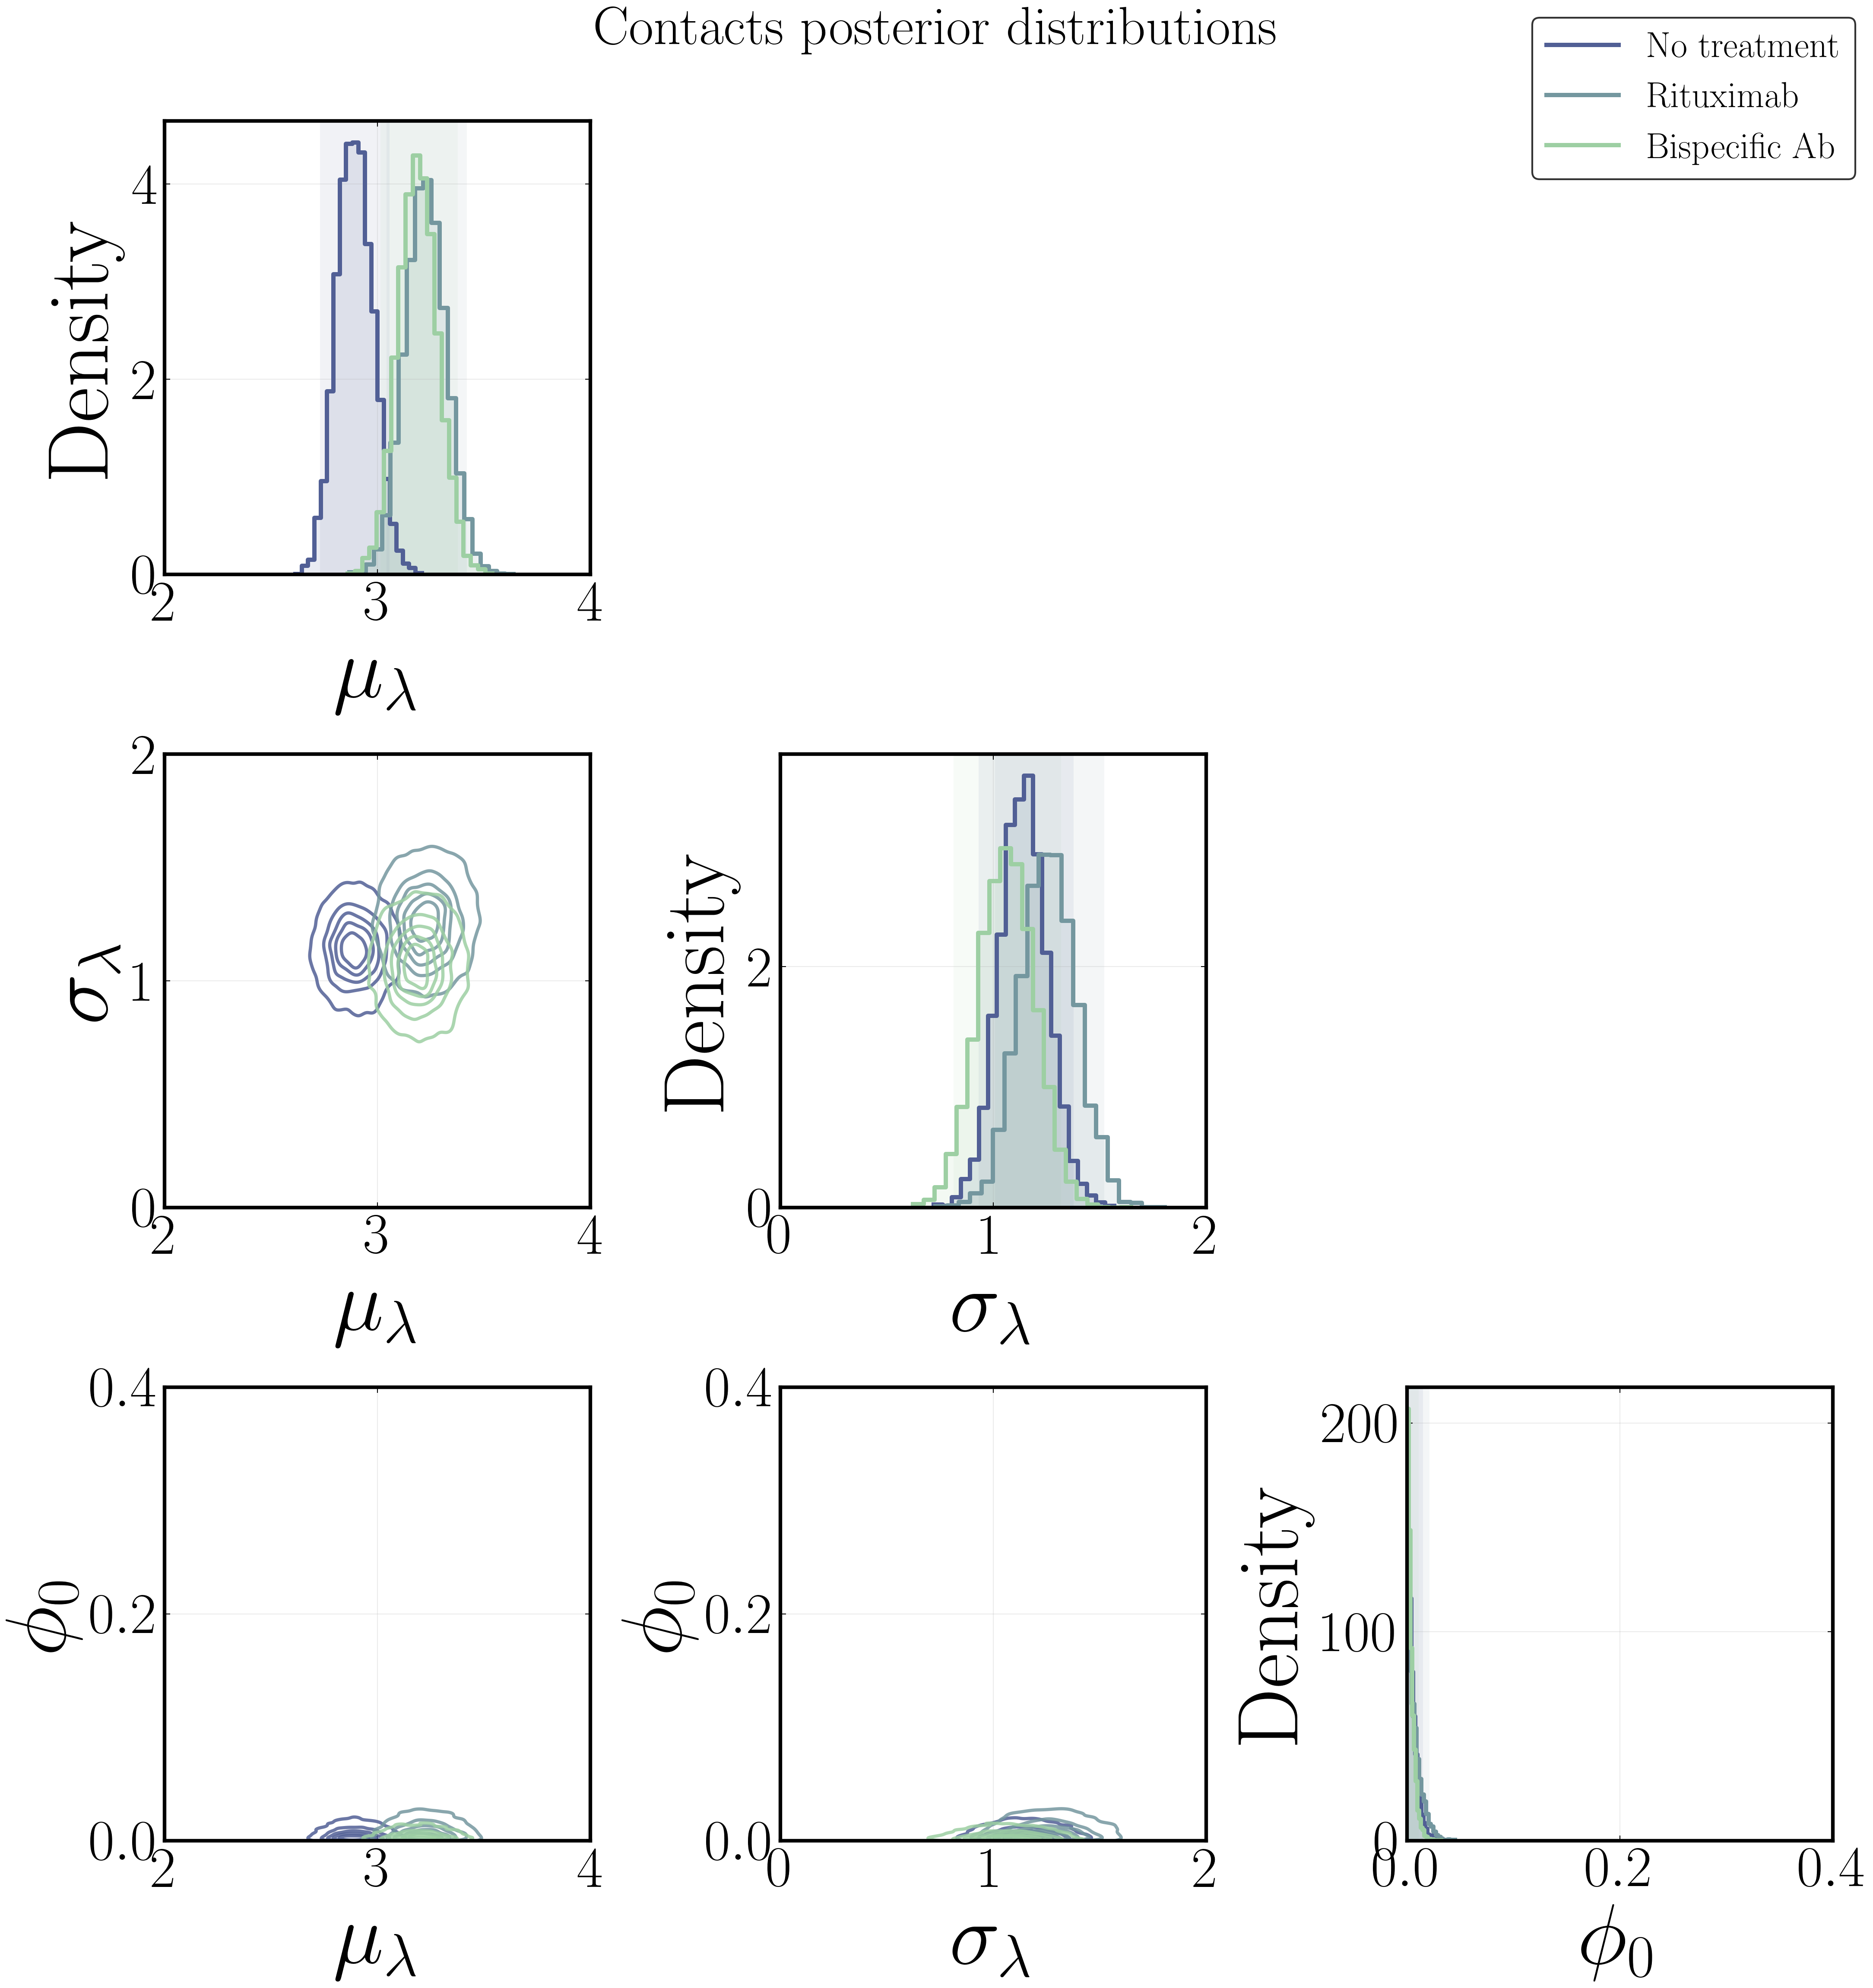

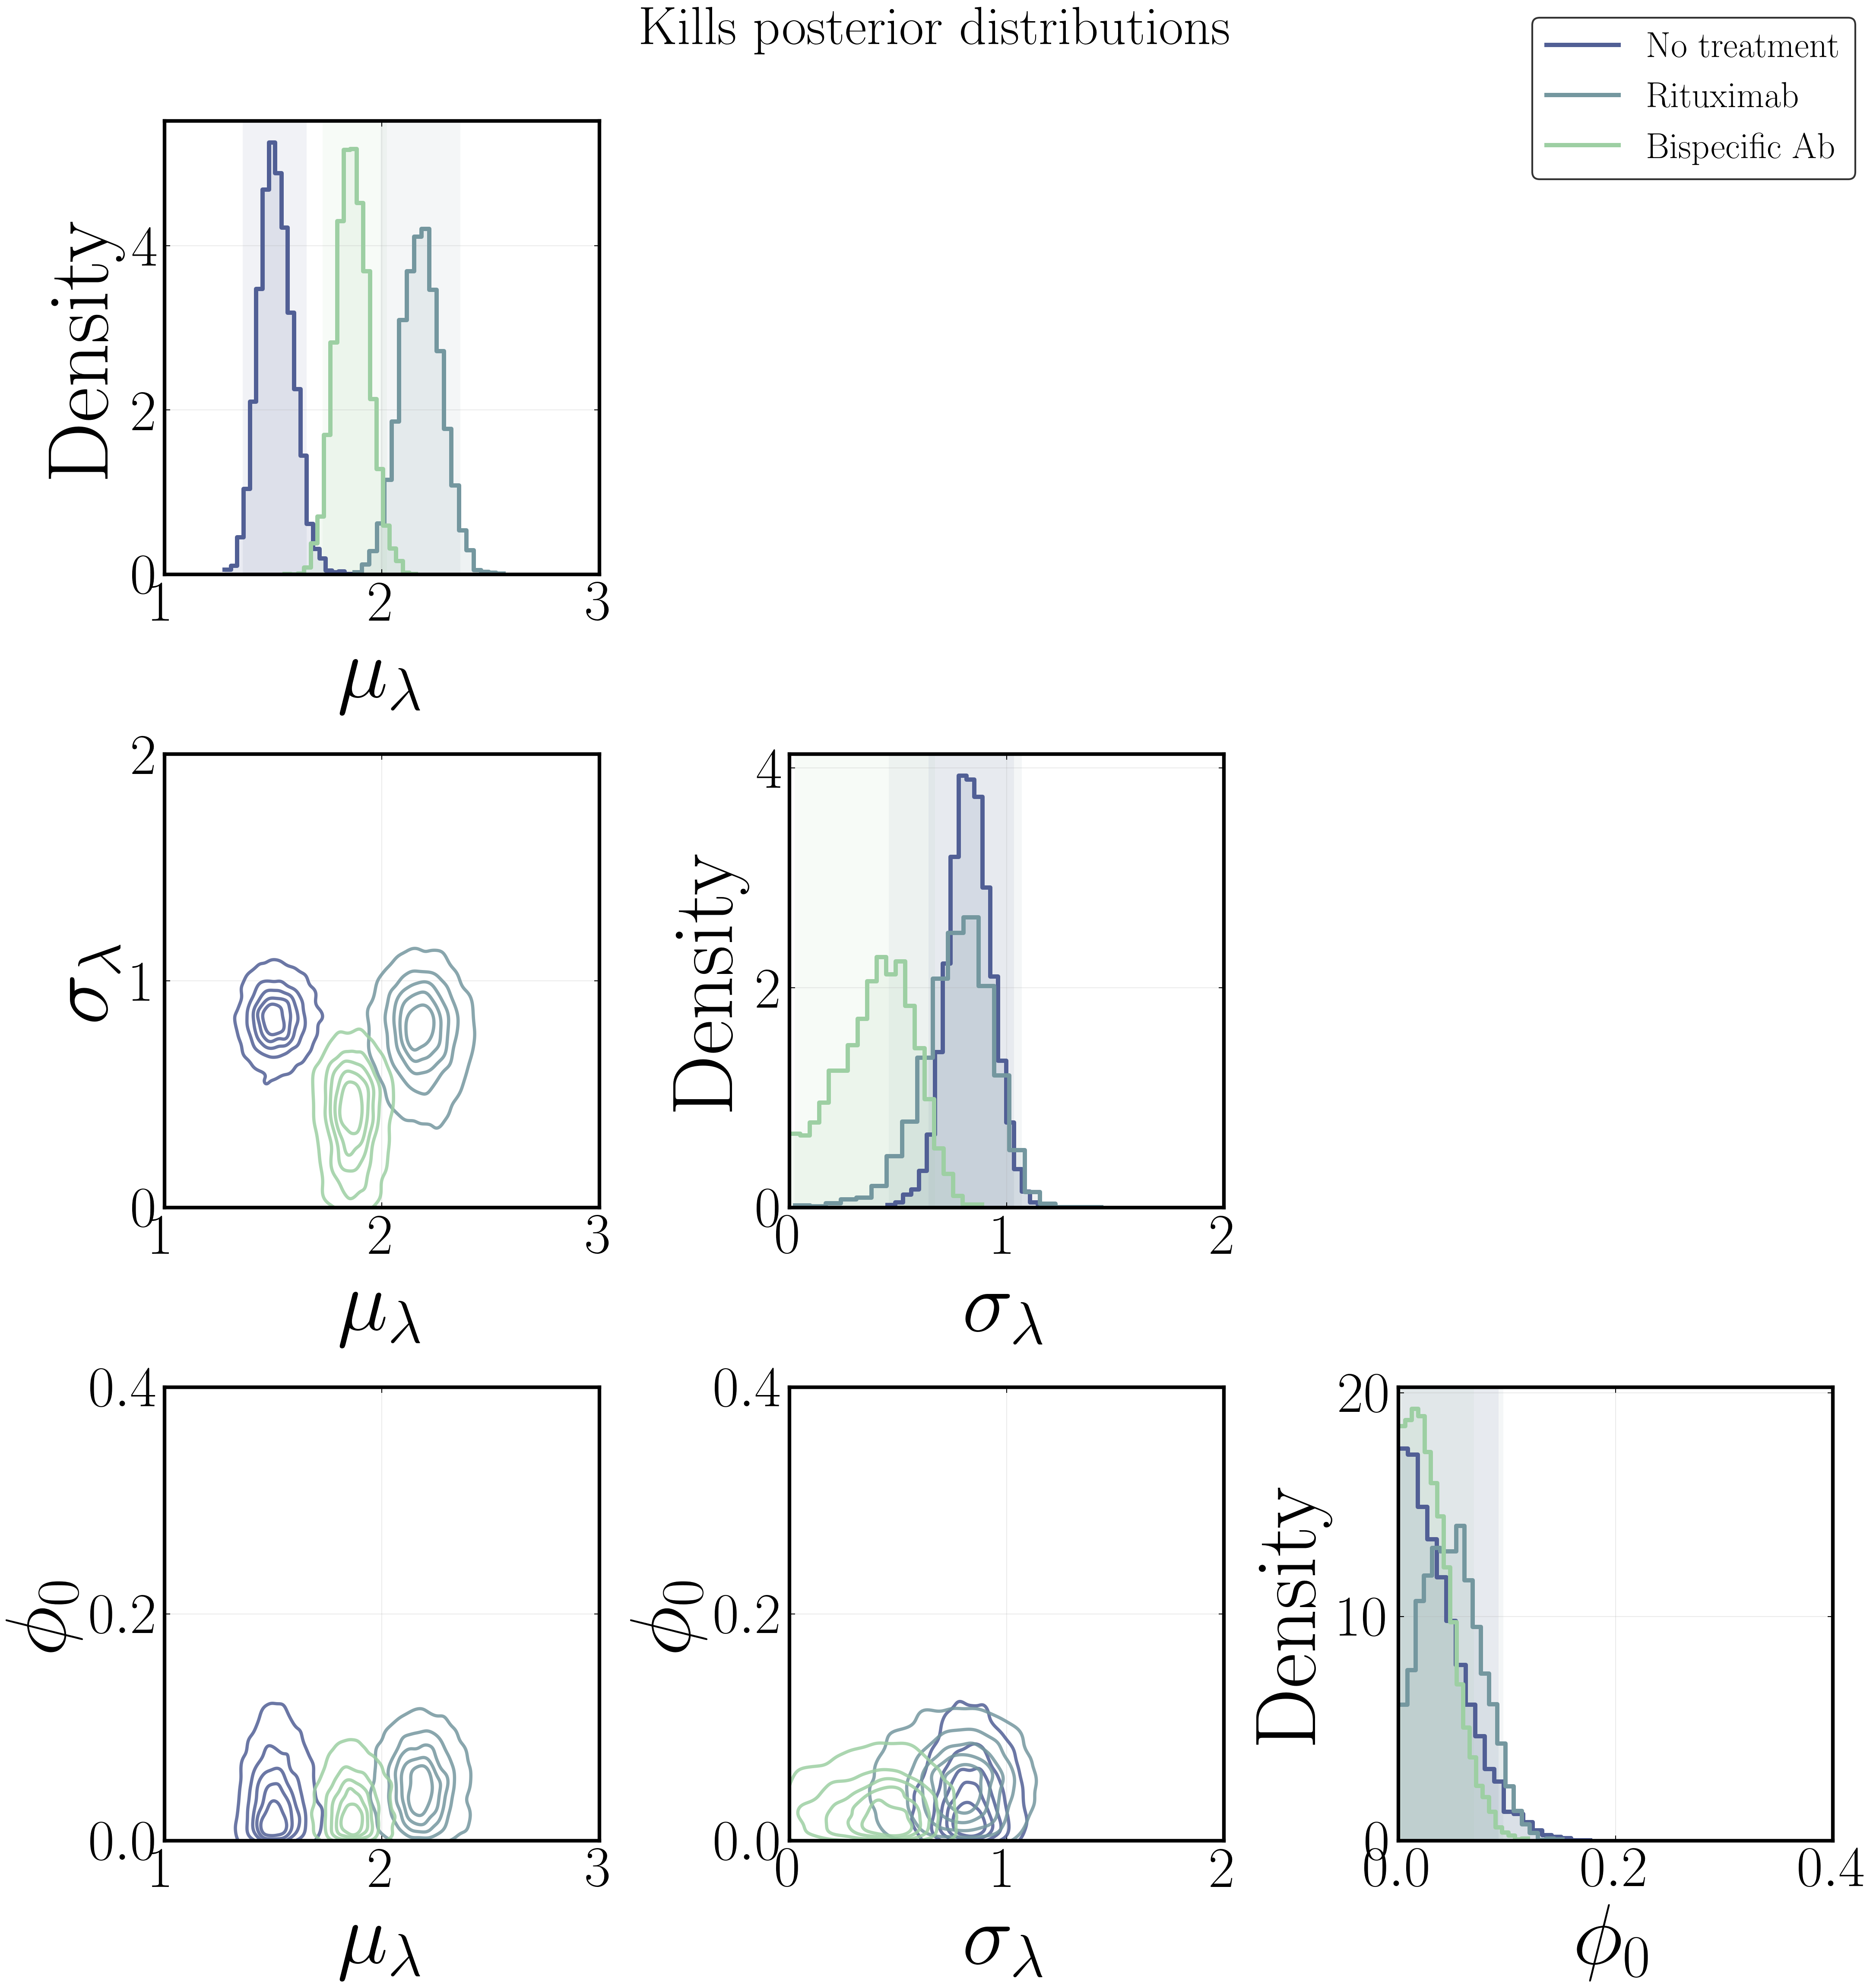

PosixPath('/Users/marsian/PhD_LifeSciRes/Orca/section_2/figures/analysis_1/gamma_posterior_three_conditions_kills.svg')

In [22]:
PARAM_DISPLAY = {
    "mu_lambda": r"$\mu_\lambda$",
    "sigma_lambda": r"$\sigma_\lambda$",
    "p_zero": r"$\phi_0$",
}

ZI_GAMMA_PARAMS = ["mu_lambda", "sigma_lambda", "p_zero"]

plot_gamma_posteriors_three_conditions(
    posterior_data,
    outcome="contacts",
    model_name="hetero3",
    parameters=ZI_GAMMA_PARAMS,
    param_limits={
        "mu_lambda": (2, 4),
        "sigma_lambda": (0, 2),
        "p_zero": (0, 0.4),
    },
)

plot_gamma_posteriors_three_conditions(
    posterior_data,
    outcome="kills",
    model_name="hetero3",
    parameters=ZI_GAMMA_PARAMS,
    param_limits={
        "mu_lambda": (1, 3),
        "sigma_lambda": (0, 2),
        "p_zero": (0, 0.4),
    },
)